# Low Default Portfolio Credit Risk Modeling

**Probability of Default estimation with Pluto–Tasche, Wilson intervals and hierarchical modeling**

**Author:** Vincent Haïk Karakoseian  
**Context:** Individual academic project conducted in collaboration with EY Quantitative Advisory Services (QAS), Financial Services.

## Project overview

This notebook studies Probability of Default (PD) estimation for **Low Default Portfolios (LDPs)**, where the scarcity of observed defaults makes naive empirical estimates unstable and potentially insufficiently conservative.

The workflow includes:

- data cleaning and credit-risk feature filtering;
- construction of a lower-risk **semi-LDP** used as a statistical benchmark;
- repeated random sampling to generate sparse-default portfolios;
- classical **Pluto–Tasche** prudent PD estimation;
- **Wilson score intervals** and upper-bound PD estimation;
- a **hierarchical / empirical-Bayes extension** with shrinkage across rating segments;
- comparison of empirical, classical, hierarchical and Wilson estimates.

> **Reproducibility note:** the raw dataset is not embedded in this notebook. The code expects it under the repository's `data/` directory. Large or restricted datasets should not be committed to GitHub.


## 0. Setup and imports


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import norm
import warnings
from scipy.optimize import OptimizeWarning
from scipy.optimize import minimize
from scipy.special import betaln

## 1. Data preparation


In [ ]:
# Data engineering part

# Robust CSV loading
# The dataset is read using a flexible parsing configuration to handle potential formatting issues
# Repository-relative paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_DIR / "loan_data_2007_2014.csv"
CLEAN_DATA_PATH = DATA_DIR / "loan_data_clean.csv"

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at {RAW_DATA_PATH}. "
        "Place the dataset in the repository's data/ directory before running this section."
    )

path = RAW_DATA_PATH

df = pd.read_csv(
    path,
    sep=";",
    engine="python",
    quotechar='"',          # Text fields enclosed in double quotes
    escapechar="\\",        # Handles escaped characters such as \"
    on_bad_lines="skip",    # Skips malformed lines
    na_values=["", " ", "NA", "N/A", "null", "None"]  # Standard missing value representations
)

# Clean column names (remove leading/trailing spaces if any)
df.columns = df.columns.str.strip()

# Convert percentage columns (int_rate, revol_util) to numeric format
# Removes the "%" symbol and converts values to float
for col in ["int_rate", "revol_util"]:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
                  .str.strip()
                  .str.replace("%", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert loan term to number of months (e.g., "36 months" → 36)
if "term" in df.columns:
    df["term_months"] = (
        df["term"].astype(str)
                  .str.extract(r"(\d+)", expand=False)
    )
    df["term_months"] = pd.to_numeric(df["term_months"], errors="coerce")

# Robust parsing of date columns formatted like:
# "Dec-11", "Apr-99", or French equivalents such as "janv-85", "juin-14", etc.
MONTH_MAP = {
    # English abbreviations
    "jan": "Jan", "feb": "Feb", "mar": "Mar", "apr": "Apr", "may": "May", "jun": "Jun",
    "jul": "Jul", "aug": "Aug", "sep": "Sep", "oct": "Oct", "nov": "Nov", "dec": "Dec",
    # Common French abbreviations
    "janv": "Jan", "févr": "Feb", "fevr": "Feb", "fév": "Feb", "fev": "Feb",
    "mars": "Mar", "avr": "Apr", "mai": "May", "juin": "Jun", "juil": "Jul",
    "août": "Aug", "aout": "Aug", "sept": "Sep", "oct": "Oct", "nov": "Nov",
    "déc": "Dec", "dec": "Dec"
}

def parse_month_year(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()

    # Replace French/English month prefixes with standard English abbreviations
    for k, v in MONTH_MAP.items():
        s = s.str.replace(rf"^{k}-", f"{v}-", regex=True)

    # Convert "Mon-YY" format into datetime (first day of the month)
    return pd.to_datetime(s, format="%b-%y", errors="coerce")

date_cols = ["issue_d", "earliest_cr_line", "last_pymnt_d",
             "next_pymnt_d", "last_credit_pull_d"]

for c in date_cols:
    if c in df.columns:
        df[c] = parse_month_year(df[c])

# Convert ID columns to nullable integers (avoids .0 formatting)
for c in ["id", "member_id"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

# Remove columns that contain only missing values
df = df.dropna(axis=1, how="all")

# Drop unused or irrelevant columns
cols_to_drop = [
    "annual_inc_joint",
    "dti_joint",
    "verification_status_joint",
    "open_acc_6m",
    "open_il_6m",
    "open_il_12m",
    "open_il_24m",
    "mths_since_rcnt_il",
    "total_bal_il",
    "il_util",
    "open_rv_12m",
    "open_rv_24m",
    "max_bal_bc",
    "all_util",
    "inq_fi",
    "total_cu_tl",
    "Unnamed: 0",
    "Unnamed: 75",
    "Unnamed: 76",
    "Unnamed: 78",
    "Unnamed: 80"
]

df = df.drop(columns=cols_to_drop, errors="ignore")

# Display first rows to verify cleaning
print(df.head(5))

        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  1077501    1296599     5000.0       5000.0           4975.0   36 months   
1  1077430    1314167     2500.0       2500.0           2500.0   60 months   
2  1077175    1313524     2400.0       2400.0           2400.0   36 months   
3  1076863    1277178    10000.0      10000.0          10000.0   36 months   
4  1075358    1311748     3000.0       3000.0           3000.0   60 months   

   int_rate  installment grade sub_grade  ... last_pymnt_amnt  \
0     10.65       162.87     B        B2  ...          171.62   
1     15.27        59.83     C        C4  ...          119.66   
2     15.96        84.33     C        C5  ...          649.91   
3     13.49       339.31     C        C1  ...          357.48   
4     12.69        67.79     B        B5  ...           67.79   

  collections_12_mths_ex_med mths_since_last_major_derog  policy_code  \
0                        0.0                         NaN          1

In [ ]:
# Save the cleaned dataset locally
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"Clean dataset saved to: {CLEAN_DATA_PATH}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv(
    CLEAN_DATA_PATH,
    sep=";",
    engine="python"
)

#df = df.drop(columns=["Unnamed: 58"], errors="ignore")

Un **portefeuille à faible nombre de défauts (Low Default Portfolio, LDP)** est souvent défini par un **nombre limité de défauts (< 20)** plutôt que par un **taux de défaut** spécifique. Cela signifie que la caractéristique déterminante d’un LDP n’est pas principalement un faible pourcentage de défauts, mais un **faible nombre absolu de défauts observés**, généralement inférieur à 20.

Pour cette raison, la première étape ne doit pas consister à construire directement un LDP strict, mais plutôt à définir un portefeuille « **semi-LDP** ». Un semi-LDP est un portefeuille déjà peu risqué, mais qui contient encore trop de défauts pour être considéré comme un véritable LDP. Il doit satisfaire trois conditions :
(1) il ne doit pas encore être qualifié de LDP (c’est-à-dire qu’il doit contenir **plus de 20 défauts**),
(2) il doit présenter un **taux de défaut significativement plus faible** que celui du portefeuille initial complet,
(3) il doit conserver un **nombre suffisant de défauts** pour permettre une **estimation fréquentiste statistiquement fiable**.

La justification méthodologique est la suivante. Une fois le semi-LDP défini (à partir de **critères quantitatifs et qualitatifs**), on peut effectuer un **sous-échantillonnage aléatoire de 5 à 10 %** des observations. Si un véritable LDP est défini par un nombre de défauts inférieur à 20, alors, avec un sous-échantillonnage aléatoire de 10 %, le semi-LDP devrait contenir **entre 200 et 300 défauts** afin de disposer de suffisamment de données.

L’avantage clé de cette approche est que la **PD « réelle » du portefeuille parent** (le semi-LDP) est **statistiquement fiable** grâce à son nombre suffisamment élevé de défauts. Les sous-échantillons LDP peuvent ainsi être utilisés pour tester différentes **techniques d’estimation** (Pluto–Tasche, approches a priori, méthodes bayésiennes hiérarchiques, procédures bootstrap, etc.) et pour évaluer dans quelle mesure ces méthodes permettent de retrouver le **niveau de risque sous-jacent**.

Le processus complet peut donc être résumé comme suit :

1. Définir un portefeuille semi-LDP à l’aide de **critères économiquement justifiés** (par exemple, un filtrage basé sur les quantiles).

2. Effectuer des **sous-échantillonnages aléatoires répétés (5–10 %)** afin de générer des portefeuilles comportant **moins de 20 défauts**.

3. Appliquer des **techniques d’estimation LDP** à ces sous-échantillons.

4. Utiliser éventuellement des **méthodes bootstrap** pour reconstruire des scénarios de défaut et comparer les estimateurs fréquentistes à la distribution de référence du semi-LDP.

5. Comparer les estimations obtenues sur les échantillons LDP avec la **PD estimée sur le semi-LDP**, qui sert de **benchmark statistiquement valide**.


## 2. Semi-LDP construction


In [ ]:
# Criterion 1

# The higher the grade, the lower the default probability, simpliest criterion

# Définition du défaut
bad_status = [
    "Default",
    "Charged Off",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)"
]

# Création du flag défaut
df["default_flag"] = df["loan_status"].isin(bad_status).astype(int)

# Calcul N, k et PD par grade
summary_grade = df.groupby("grade")["default_flag"].agg(
    N="count",
    k="sum",
    Default_rate="mean"
).reset_index()

print(summary_grade)

  grade       N      k  Default_rate
0     A   69354   2710      0.039075
1     B  126093  10025      0.079505
2     C  114382  13223      0.115604
3     D   70325  10891      0.154867
4     E   33115   6451      0.194806
5     F   12358   2999      0.242677
6     G    3117    866      0.277831


Les **grades A et B** sont clairement les plus sûrs, avec des **taux de défaut de 4 % et 8 %**. Nous conserverons également le **grade B** afin de **maintenir un volume de données suffisant**, puis nous les filtrerons davantage à l’aide d’**autres critères**.


In [ ]:
semi_ldp = df[df["grade"].isin(["A", "B"])]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

195447
12735
6.515832936806397


Un **taux de défaut de 6,5 %** avec **12 735 défauts** est largement trop élevé ; nous devons **affiner davantage la sélection**.


In [ ]:
# Criterion 2

# Shorter-term loans are generally less risky than long-term ones
# Since here we only have 2 maturities, we will keep the smallest one

semi_ldp = semi_ldp[semi_ldp["term"]==" 36 months"]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

177508
11420
6.433512855758614


Un **taux de défaut de 6,4 %** avec **11 420 défauts** reste beaucoup trop élevé ; nous devons **pousser encore plus loin la sélection**.


In [ ]:
# Criterion 3

def to_float(x):
    try:
        return float(x)
    except:
        return None


semi_ldp["dti"] = semi_ldp["dti"].apply(to_float)

# A lower DTI means that the borrower has less debt compared to their income,
# which generally indicates a stronger ability to repay the loan.

# Bornes exactes des quantiles
quantile_values = semi_ldp["dti"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]).values

quantiles = semi_ldp["dti"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.9, 1])
print(quantiles)

# Création des tranches selon ces bornes
semi_ldp["dti_bucket"] = pd.cut(
    semi_ldp["dti"],
    bins=quantile_values,
    include_lowest=True,
    duplicates="drop"
)

# Calcul du taux de défaut par tranche
dti_summary = semi_ldp.groupby("dti_bucket")["default_flag"].agg(
    N="count",
    k="sum",
    PD="mean"
).reset_index()

print(dti_summary)

0.00     0.00
0.10     6.26
0.25    10.32
0.50    15.51
0.75    21.28
0.90    26.33
1.00    39.98
Name: dti, dtype: float64
       dti_bucket      N     k        PD
0  (-0.001, 6.26]  17562   909  0.051759
1   (6.26, 10.32]  26299  1397  0.053120
2  (10.32, 15.51]  43774  2549  0.058231
3  (15.51, 21.28]  43818  2982  0.068054
4  (21.28, 26.33]  26311  1990  0.075634
5  (26.33, 39.98]  17497  1410  0.080585


/tmp/ipykernel_147/2945971602.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_summary = semi_ldp.groupby("dti_bucket")["default_flag"].agg(


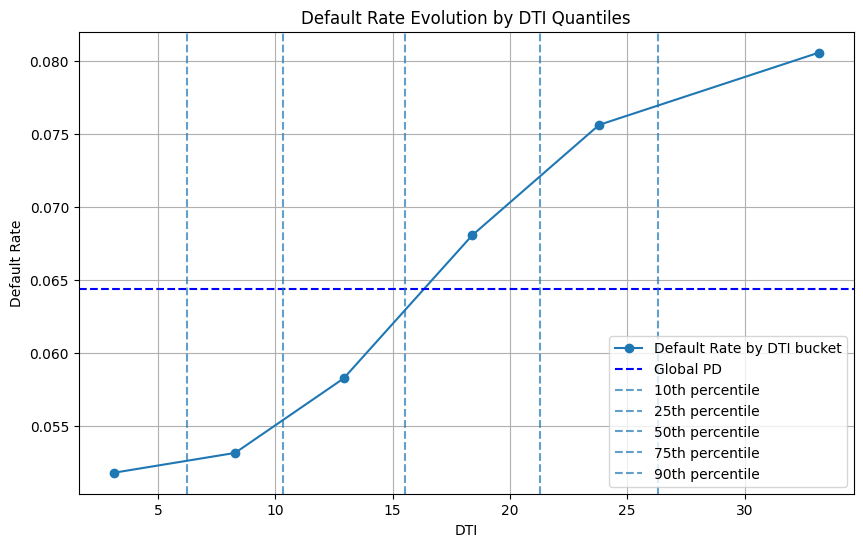

In [ ]:
# Compute bucket centers for plotting
bucket_centers = [
    (interval.left + interval.right) / 2
    for interval in dti_summary["dti_bucket"]
]

# Global default rate
PD_global = semi_ldp["default_flag"].mean()

plt.figure(figsize=(10,6))

# Plot default rate by DTI bucket
plt.plot(bucket_centers, dti_summary["PD"], marker='o', label="Default Rate by DTI bucket")

# Horizontal line for overall portfolio PD
plt.axhline(PD_global, linestyle='--', color='blue', label="Global PD")

# List of percentiles to display
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]

for p in percentiles:
    q_value = semi_ldp["dti"].quantile(p)
    plt.axvline(q_value, linestyle='--', alpha=0.7, label=f"{int(p*100)}th percentile")

plt.xlabel("DTI")
plt.ylabel("Default Rate")
plt.title("Default Rate Evolution by DTI Quantiles")
plt.legend()
plt.grid(True)

plt.show()

L’analyse graphique montre que le **taux de défaut** demeure relativement stable jusqu’au **75ᵉ percentile** de la distribution du **DTI**. Au-delà de ce seuil, le taux de défaut augmente fortement et de manière continue.

Ainsi, le **75ᵉ percentile** constitue un **seuil statistiquement et économiquement justifié**, permettant de conserver une large part du portefeuille tout en excluant le segment où le **risque de crédit** s’accroît significativement.


In [ ]:

q75 = semi_ldp["dti"].quantile(0.75)

semi_ldp = semi_ldp[semi_ldp["dti"]<=q75]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

131453
7837
5.961826660479411


Un **taux de défaut de 6 %** avec **7 837 défauts** est encore beaucoup trop élevé ; nous devons **affiner davantage la sélection**.


In [ ]:
# Criterion 4


# Convert int_rate to float
semi_ldp["int_rate"] = semi_ldp["int_rate"].apply(to_float)

# Create default flag (if not already created)
bad_status = [
    "Default",
    "Charged Off",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)"
]
semi_ldp["default_flag"] = semi_ldp["loan_status"].isin(bad_status).astype(int)

# Compute quantiles
q_levels = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 1]
quantiles = semi_ldp["int_rate"].quantile(q_levels)
print(quantiles)

# Build buckets using these quantile cutoffs
quantile_values = quantiles.values

semi_ldp["int_rate_bucket"] = pd.cut(
    semi_ldp["int_rate"],
    bins=quantile_values,
    include_lowest=True,
    duplicates="drop"
)

# Default rate by bucket
int_rate_summary = semi_ldp.groupby("int_rate_bucket")["default_flag"].agg(
    N="count",
    k="sum",
    PD="mean"
).reset_index()

print(int_rate_summary)

0.00     5.42
0.10     6.62
0.25     7.90
0.50    10.15
0.75    11.86
0.90    12.99
1.00    14.09
Name: int_rate, dtype: float64
  int_rate_bucket      N     k        PD
0   (5.419, 6.62]  16362   365  0.022308
1     (6.62, 7.9]  22671   893  0.039390
2    (7.9, 10.15]  30200  1466  0.048543
3  (10.15, 11.86]  29400  2079  0.070714
4  (11.86, 12.99]  22379  1841  0.082265
5  (12.99, 14.09]  10441  1193  0.114261


/tmp/ipykernel_147/3833399216.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  int_rate_summary = semi_ldp.groupby("int_rate_bucket")["default_flag"].agg(


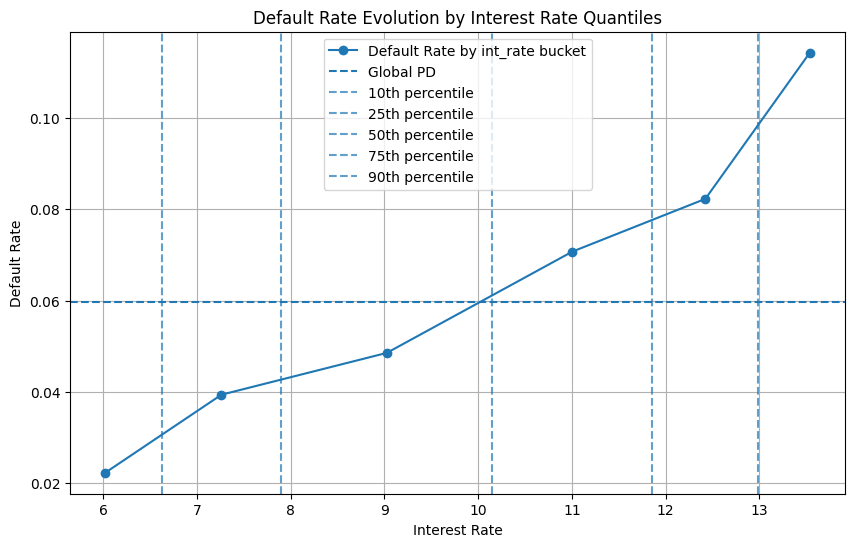

In [ ]:
# Compute bucket centers for plotting
bucket_centers = [
    (interval.left + interval.right) / 2
    for interval in int_rate_summary["int_rate_bucket"]
]

# Global default rate (benchmark reference)
PD_global = semi_ldp["default_flag"].mean()

plt.figure(figsize=(10,6))

# Plot default rate by int_rate bucket
plt.plot(bucket_centers, int_rate_summary["PD"], marker='o', label="Default Rate by int_rate bucket")

# Horizontal line for overall portfolio PD
plt.axhline(PD_global, linestyle='--', label="Global PD")

# Add vertical lines for key percentiles
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]
for p in percentiles:
    q_value = semi_ldp["int_rate"].quantile(p)
    plt.axvline(q_value, linestyle='--', alpha=0.7, label=f"{int(p*100)}th percentile")

plt.xlabel("Interest Rate")
plt.ylabel("Default Rate")
plt.title("Default Rate Evolution by Interest Rate Quantiles")
plt.legend()
plt.grid(True)
plt.show()

Le **taux de défaut** augmente de manière régulière avec le **taux d’intérêt**. Le **50ᵉ percentile** constitue la première **rupture structurelle**, où le taux de défaut dépasse la moyenne du portefeuille et commence à s’accélérer.

Ainsi, retenir la **médiane comme seuil** offre un **compromis équilibré** entre la **réduction du risque** et la **préservation de la taille de l’échantillon**.


In [ ]:

q50 = semi_ldp["int_rate"].quantile(0.50)

semi_ldp = semi_ldp[semi_ldp["int_rate"]<=q50]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

69233
2724
3.934539887048084


Un **taux de défaut de 3,9 %** avec **2 724 défauts** reste beaucoup trop élevé ; nous devons **approfondir encore la sélection**.


In [ ]:
# Criterion 5

# Convert annual income to float
semi_ldp["annual_inc"] = semi_ldp["annual_inc"].apply(to_float)

# Ensure default flag exists
bad_status = [
    "Default",
    "Charged Off",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)"
]
semi_ldp["default_flag"] = semi_ldp["loan_status"].isin(bad_status).astype(int)

# Compute quantiles
q_levels = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 1]
quantiles = semi_ldp["annual_inc"].quantile(q_levels)
print(quantiles)

# Create quantile buckets
quantile_values = quantiles.values

semi_ldp["income_bucket"] = pd.cut(
    semi_ldp["annual_inc"],
    bins=quantile_values,
    include_lowest=True,
    duplicates="drop"
)

# Default rate by income bucket
income_summary = semi_ldp.groupby("income_bucket")["default_flag"].agg(
    N="count",
    k="sum",
    PD="mean"
).reset_index()

print(income_summary)

0.00       2000.0
0.10      37000.0
0.25      50000.0
0.50      72000.0
0.75     100000.0
0.90     140000.0
1.00    4900000.0
Name: annual_inc, dtype: float64
           income_bucket      N    k        PD
0    (1999.999, 37000.0]   6931  552  0.079642
1     (37000.0, 50000.0]  10522  556  0.052842
2     (50000.0, 72000.0]  17360  636  0.036636
3    (72000.0, 100000.0]  17522  568  0.032416
4   (100000.0, 140000.0]  10423  268  0.025712
5  (140000.0, 4900000.0]   6471  144  0.022253


/tmp/ipykernel_147/1977953255.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_summary = semi_ldp.groupby("income_bucket")["default_flag"].agg(


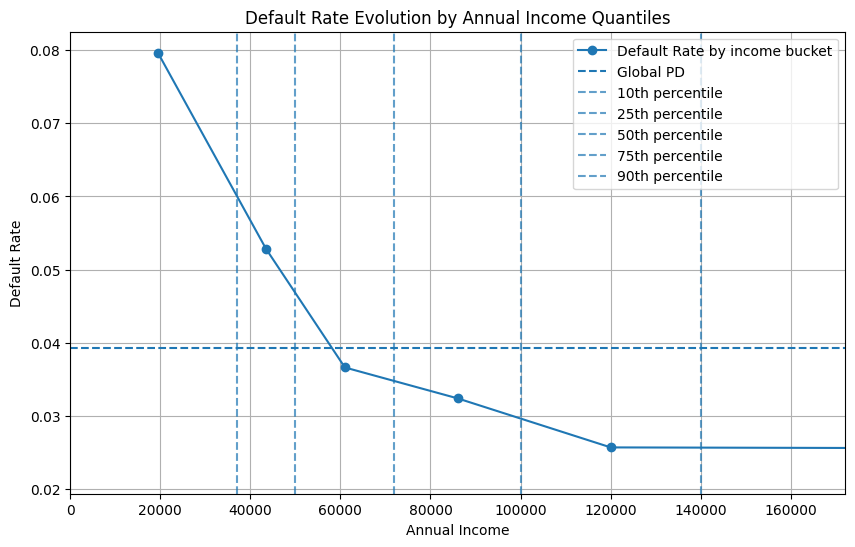

In [ ]:
# Compute bucket centers
bucket_centers = [
    (interval.left + interval.right) / 2
    for interval in income_summary["income_bucket"]
]

# Global default rate
PD_global = semi_ldp["default_flag"].mean()

plt.figure(figsize=(10,6))

plt.plot(bucket_centers, income_summary["PD"], marker='o', label="Default Rate by income bucket")

plt.axhline(PD_global, linestyle='--', label="Global PD")

# Vertical lines for percentiles
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]
for p in percentiles:
    q_value = semi_ldp["annual_inc"].quantile(p)
    plt.axvline(q_value, linestyle='--', alpha=0.7, label=f"{int(p*100)}th percentile")

plt.xlim(0, semi_ldp["annual_inc"].quantile(0.95)) # Otherwise, the graph will be too crushed beacause of the outlier

plt.xlabel("Annual Income")
plt.ylabel("Default Rate")
plt.title("Default Rate Evolution by Annual Income Quantiles")
plt.legend()
plt.grid(True)

plt.show()

Le **taux de défaut** diminue fortement à mesure que le **revenu annuel** augmente. Une **amélioration structurelle significative** apparaît entre le **50ᵉ et le 75ᵉ percentile**.

Au-delà du **75ᵉ percentile**, la réduction marginale du risque de défaut devient limitée, tandis que la **taille de l’échantillon** diminue fortement.

Ainsi, retenir le **75ᵉ percentile** offre le **meilleur compromis** entre **réduction du risque** et **robustesse statistique**.


In [ ]:

q75 = semi_ldp["annual_inc"].quantile(0.75)
semi_ldp = semi_ldp[semi_ldp["annual_inc"] >= q75]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

18625
467
2.5073825503355707


Un **taux de défaut de 1,9 %** avec **467 défauts** reste encore trop élevé ; nous devons **affiner davantage la sélection**.


In [ ]:
# Criterion 6

# Convert revol_util to float
semi_ldp["revol_util"] = semi_ldp["revol_util"].apply(to_float)

# Ensure default flag exists
bad_status = [
    "Default",
    "Charged Off",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)"
]
semi_ldp["default_flag"] = semi_ldp["loan_status"].isin(bad_status).astype(int)

# Compute quantiles
q_levels = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 1]
quantiles = semi_ldp["revol_util"].quantile(q_levels)
print(quantiles)

# Create buckets using quantile cutoffs
quantile_values = quantiles.values

semi_ldp["revol_bucket"] = pd.cut(
    semi_ldp["revol_util"],
    bins=quantile_values,
    include_lowest=True,
    duplicates="drop"
)

# Default rate by bucket
revol_summary = semi_ldp.groupby("revol_bucket")["default_flag"].agg(
    N="count",
    k="sum",
    PD="mean"
).reset_index()

print(revol_summary)

0.00      0.0
0.10     12.7
0.25     27.6
0.50     45.4
0.75     63.9
0.90     79.1
1.00    118.2
Name: revol_util, dtype: float64
     revol_bucket     N    k        PD
0  (-0.001, 12.7]  1882   41  0.021785
1    (12.7, 27.6]  2800   65  0.023214
2    (27.6, 45.4]  4633  101  0.021800
3    (45.4, 63.9]  4646  124  0.026690
4    (63.9, 79.1]  2803   81  0.028898
5   (79.1, 118.2]  1846   55  0.029794


/tmp/ipykernel_147/2488069688.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revol_summary = semi_ldp.groupby("revol_bucket")["default_flag"].agg(


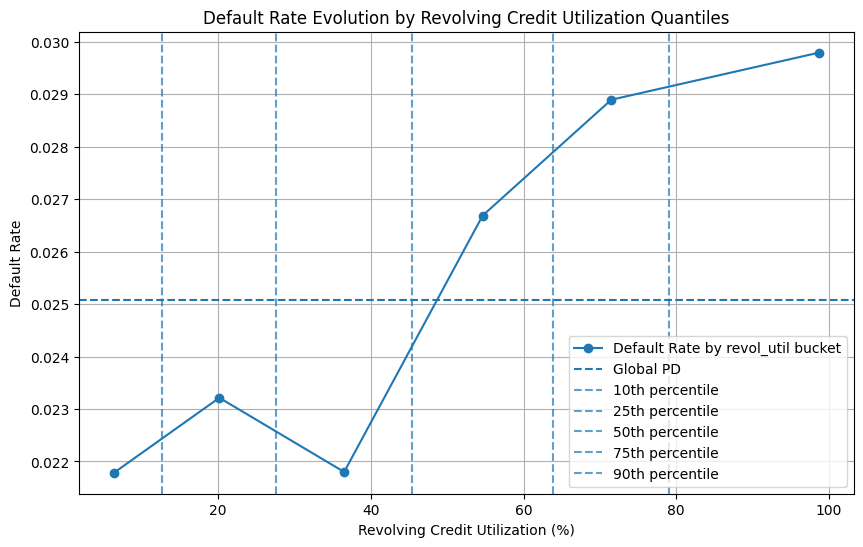

In [ ]:
# Compute bucket centers
bucket_centers = [
    (interval.left + interval.right) / 2
    for interval in revol_summary["revol_bucket"]
]

# Global default rate
PD_global = semi_ldp["default_flag"].mean()

plt.figure(figsize=(10,6))

plt.plot(bucket_centers, revol_summary["PD"], marker='o', label="Default Rate by revol_util bucket")

plt.axhline(PD_global, linestyle='--', label="Global PD")

# Vertical lines for percentiles
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]
for p in percentiles:
    q_value = semi_ldp["revol_util"].quantile(p)
    plt.axvline(q_value, linestyle='--', alpha=0.7, label=f"{int(p*100)}th percentile")

plt.xlabel("Revolving Credit Utilization (%)")
plt.ylabel("Default Rate")
plt.title("Default Rate Evolution by Revolving Credit Utilization Quantiles")
plt.legend()
plt.grid(True)
plt.show()

La relation entre le **taux d’utilisation du crédit renouvelable** et le **taux de défaut** n’est pas strictement monotone et présente un **bruit statistique notable**, en particulier dans les classes d’utilisation élevées où les tailles d’échantillon sont plus faibles.

Si des niveaux d’utilisation très faibles sont associés à des taux de défaut plus bas, au-delà du **75ᵉ percentile**, les fluctuations observées reflètent vraisemblablement une **variabilité d’échantillonnage** plutôt que de véritables différences structurelles de risque.

Ainsi, le **75ᵉ percentile** constitue un **seuil prudent et statistiquement stable**.


In [ ]:

q75 = semi_ldp["revol_util"].quantile(0.75)
semi_ldp = semi_ldp[semi_ldp["revol_util"] <= q75]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

13961
331
2.370890337368383


Un **taux de défaut de 2,4 %** avec **331 défauts** reste légèrement élevé pour un **semi-LDP**, mais commence à devenir acceptable.


In [ ]:
#Criterion 7

#Homeowners or those with a mortgage tend to have greater
#financial stability than those who rent.

semi_ldp = semi_ldp[semi_ldp["home_ownership"].isin(["OWN", "MORTGAGE"])]

In [ ]:
# Check if we have to go further or not

print(len(semi_ldp))
print(len(semi_ldp[semi_ldp["default_flag"] == True]))
print(len(semi_ldp[semi_ldp["default_flag"] == True])*100/len(semi_ldp))

10865
251
2.310170271514036


Un **taux de défaut de 2,3 %** avec **251 défauts** est satisfaisant pour un **semi-LDP** ; nous nous arrêterons donc à ce stade.


In [ ]:
SEMI_LDP_PATH = OUTPUT_DIR / "semi_ldp.csv"
semi_ldp.to_csv(SEMI_LDP_PATH, index=False, sep=";")
print(f"Semi-LDP saved to: {SEMI_LDP_PATH}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
actual_defaults = semi_ldp[
    semi_ldp["loan_status"].isin([
        "Default",
        "Charged Off",
        "Does not meet the credit policy. Status:Charged Off",
        "Late (31-120 days)"
    ])
]

print(len(actual_defaults))
print(f"Percentage of defaults :{100*len(actual_defaults)/len(semi_ldp)} %")

251
Percentage of defaults :2.310170271514036 %


In [ ]:
DEFAULTS_PATH = OUTPUT_DIR / "actual_defaults.csv"
actual_defaults.to_csv(DEFAULTS_PATH, index=False, sep=";")
print(f"Observed defaults saved to: {DEFAULTS_PATH}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Random sampling of sparse-default portfolios


1000 samples generated.
Sample size = 1086
Min defaults: 9
Max defaults: 45
Mean defaults: 25.33
1000 different LDPs


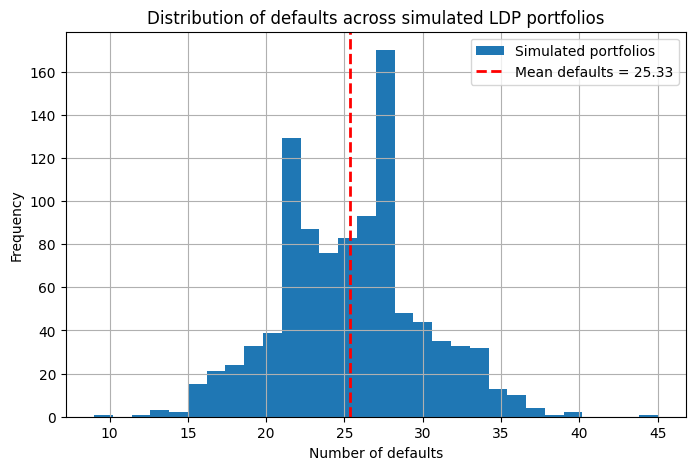

In [ ]:
# Parameters
sample_fraction = 0.10   # 10% sampling
n_samples = 1000         # number of random samples
random_seed = 31

np.random.seed(random_seed)

samples_10pct = []

for i in range(n_samples):
    sample_i = semi_ldp.sample(frac=sample_fraction, replace=False)
    samples_10pct.append(sample_i)

print(f"{len(samples_10pct)} samples generated.")
print(f"Sample size = {len(samples_10pct[0])}")

default_counts = []

for sample in samples_10pct:
    k = sample["default_flag"].sum()
    default_counts.append(k)

mean_defaults = np.mean(default_counts)

print("Min defaults:", min(default_counts))
print("Max defaults:", max(default_counts))
print("Mean defaults:", mean_defaults)

# Identify samples that qualify as true LDPs (<20 defaults)
ldp_ids = []

for i, y in enumerate(default_counts):
#   if default_counts[i] < 20: # Keeping all portfolios
    ldp_ids.append((i, y))

print(f"{len(ldp_ids)} different LDPs")

plt.figure(figsize=(8,5))

plt.hist(default_counts, bins=30, label="Simulated portfolios")

# Mean line
plt.axvline(
    mean_defaults,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean defaults = {mean_defaults:.2f}"
)

plt.xlabel("Number of defaults")
plt.ylabel("Frequency")
plt.title("Distribution of defaults across simulated LDP portfolios")
plt.legend()
plt.grid(True)
plt.show()

Le graphique ci-dessus représente la **distribution empirique du nombre de défauts** observés dans les **1000 portefeuilles simulés** obtenus en tirant aléatoirement **10 % des expositions** du jeu de données **semi-LDP**. On observe que la distribution est **centrée autour de valeurs comprises approximativement entre 20 et 30 défauts**.

Ce résultat est cohérent avec les **propriétés statistiques attendues du processus d’échantillonnage**. En effet, si l’on note **$p$ le taux de défaut moyen du portefeuille initial** (soit pour rappel **2,3 %**) et **$N$ la taille moyenne des portefeuilles simulés** (soit **1086**), alors le nombre de défauts observé dans un portefeuille suit approximativement une **loi binomiale $\mathrm{Bin}(N,p)$**. Dans ce cadre, **l’espérance du nombre de défauts** est donnée par $\mathbb{E}[k] = Np$. Le fait que la distribution observée soit centrée autour d’environ **25 défauts** suggère donc que **la valeur de $Np$ dans nos simulations est de cet ordre de grandeur**, ce qui est confirmé numériquement puisque **$1086 \times 0.023 \approx 25$**.

La **dispersion autour de cette valeur centrale** reflète simplement la **variabilité d’échantillonnage** inhérente au tirage aléatoire des expositions. La **forme globalement symétrique de la distribution** est également cohérente avec le fait que **$Np$ est suffisamment grand** pour que **la loi binomiale soit raisonnablement bien approchée par une loi normale**.

Enfin, on constate que la **majorité des portefeuilles simulés présentent un nombre de défauts supérieur à 20**. Autrement dit, **sans critère de filtrage supplémentaire**, la plupart des portefeuilles générés **ne relèvent pas strictement du cadre des Low Default Portfolios (LDP)**. Néanmoins, il a été choisi **de ne pas introduire de règle de filtrage** consistant à ne conserver que les portefeuilles présentant **moins de 20 défauts**. Ce choix permet de **disposer d’un nombre d’observations suffisamment important**, afin d’obtenir **des estimations de la PD plus stables** et de permettre aux **méthodes quantitatives utilisées de converger vers la PD empirique du portefeuille**.

Cependant, les **lignes de code** permettant de mettre en œuvre ce **filtrage** ont été conservées **en commentaire** dans le **pipeline**, de sorte que le **lecteur** pourra, s’il le souhaite, l’appliquer.


## 4. Classical Pluto–Tasche approach


In [ ]:
# ------------------------------------------------------------
# Pluto–Tasche prudent PD (upper bound)
# ------------------------------------------------------------
def pluto_tasche_pd_upper(N: int, k: int, alpha: float = 0.95) -> float:
    if N <= 0:
        raise ValueError("N must be > 0.")
    if (k < 0) or (k > N):
        raise ValueError("k must satisfy 0 <= k <= N.")
    if (alpha <= 0) or (alpha >= 1):
        raise ValueError("alpha must be in (0,1).")

    # Case k = 0
    if k == 0:
        return 1.0 - ((1.0 - alpha) ** (1.0 / N))

    # General case
    a = k + 1
    b = N - k
    return float(beta.ppf(alpha, a, b))


# ------------------------------------------------------------
# Semi-LDP benchmark (empirical PD)
# ------------------------------------------------------------
N_semi = len(semi_ldp)
k_semi = int(semi_ldp["default_flag"].sum())

pd_semi_emp = k_semi / N_semi                 # in decimal
pd_semi_emp_pct = 100.0 * pd_semi_emp         # in %


# ------------------------------------------------------------
# Apply Pluto–Tasche to each LDP sample
# ------------------------------------------------------------
alpha_conf = 0.95
results = []

for idx, _ in ldp_ids:
    sample_df = samples_10pct[idx]

    N_ldp = len(sample_df)
    k_ldp = int(sample_df["default_flag"].sum())

    pd_pt = pluto_tasche_pd_upper(N=N_ldp, k=k_ldp, alpha=alpha_conf)   # decimal
    pd_pt_pct = 100.0 * pd_pt                                           # %

    # Absolute difference (percentage points)
    diff_pp = pd_pt_pct - pd_semi_emp_pct

    # Relative difference (%) = (PT - benchmark) / benchmark
    # Safe division in case benchmark is 0 (should not happen here, but clean)
    rel_diff_pct = np.nan if pd_semi_emp_pct == 0 else 100.0 * (diff_pp / pd_semi_emp_pct)

    results.append({
        "ldp_id": idx,
        "ldp_size": N_ldp,
        "ldp_defaults": k_ldp,
        "pluto_tasche_pd_95_pct": pd_pt_pct,
        "semi_ldp_empirical_pd_pct": pd_semi_emp_pct,
        "pt_minus_semi_pp": diff_pp,                  # pp = percentage points
        "pt_minus_semi_relative_pct": rel_diff_pct    # relative in %
    })

# ------------------------------------------------------------
# Final DataFrame
# ------------------------------------------------------------
ldp_results_df = pd.DataFrame(results)

print(ldp_results_df.head())
print("Number of LDP samples analysed:", len(ldp_results_df))

   ldp_id  ldp_size  ldp_defaults  pluto_tasche_pd_95_pct  \
0       0      1086            28                3.517933   
1       1      1086            25                3.200396   
2       2      1086            27                3.412361   
3       3      1086            31                3.833164   
4       4      1086            27                3.412361   

   semi_ldp_empirical_pd_pct  pt_minus_semi_pp  pt_minus_semi_relative_pct  
0                    2.31017          1.207763                   52.280247  
1                    2.31017          0.890225                   38.535057  
2                    2.31017          1.102191                   47.710380  
3                    2.31017          1.522993                   65.925587  
4                    2.31017          1.102191                   47.710380  
Number of LDP samples analysed: 1000


### 4.1 Bias diagnostics: Pluto–Tasche vs empirical PD


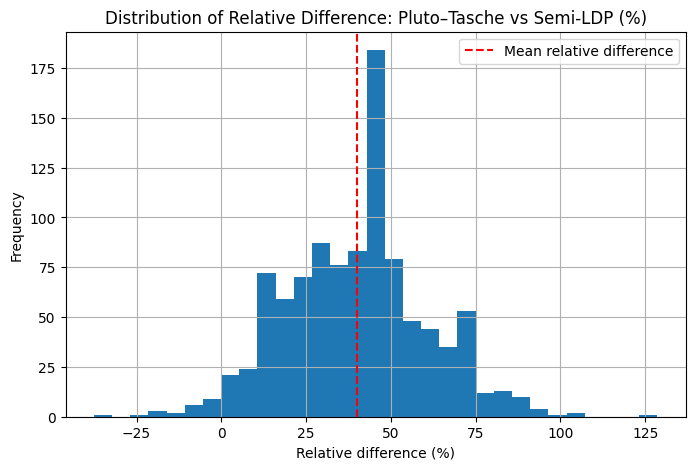

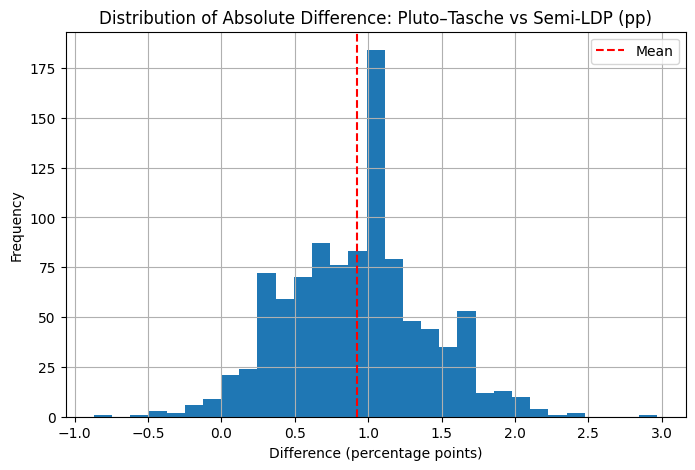

In [ ]:
# ------------------------------------------------------------
# Histogram of relative difference
# ---------------------------------------------------------
diff_rel = ldp_results_df["pt_minus_semi_relative_pct"]

plt.figure(figsize=(8,5))
plt.hist(diff_rel, bins='auto')

plt.axvline(
    diff_rel.mean(),
    linestyle="--",
    color="red",
    label="Mean relative difference"
)

plt.title("Distribution of Relative Difference: Pluto–Tasche vs Semi-LDP (%)")
plt.xlabel("Relative difference (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Histogram of absolute difference (percentage points)
# ------------------------------------------------------------
diff_pp = ldp_results_df["pt_minus_semi_pp"]

plt.figure(figsize=(8,5))
plt.hist(diff_pp, bins='auto')

plt.axvline(
    diff_pp.mean(),
    linestyle="--",
    label="Mean",
    color='red'
)

plt.title("Distribution of Absolute Difference: Pluto–Tasche vs Semi-LDP (pp)")
plt.xlabel("Difference (percentage points)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

Le premier graphique représente la distribution de l’**écart relatif** entre la **PD prudente estimée par la méthode de Pluto–Tasche** et la **PD empirique** du portefeuille semi-LDP, exprimé en pourcentage de la PD de référence. Une valeur positive correspond à une estimation plus prudente que la PD empirique, tandis qu’une valeur négative indique une sous-estimation relative.

On observe que la distribution est majoritairement située au-dessus de zéro et que la **moyenne de l’écart relatif** (ligne rouge pointillée) est nettement positive, autour de **40 à 50 %**. Cela signifie qu’en moyenne, la méthode de Pluto–Tasche produit une estimation de PD significativement supérieure à la PD empirique du portefeuille. Ce comportement est cohérent avec l’objectif même de la méthode, qui consiste à fournir une **estimation prudente de la probabilité de défaut** dans les contextes de **Low Default Portfolios (LDP)**.

Cette prudence s’explique directement par la construction du modèle. En effet, la méthode de Pluto–Tasche repose sur le calcul d’un **quantile élevé de la distribution Beta** associée à la probabilité de défaut. Autrement dit, au lieu d’utiliser l’estimateur empirique (k/N), la méthode sélectionne une valeur située dans la **queue supérieure de la distribution plausible de la PD**. Cette approche introduit mécaniquement un **biais prudentiel positif**, particulièrement visible lorsque le nombre de défauts observés est faible.

Le retrait du filtre consistant à ne conserver que les portefeuilles présentant **moins de 20 défauts** entraîne toutefois une **dispersion plus importante** de la distribution des écarts relatifs. On observe notamment des valeurs pouvant dépasser **100 %**, ce qui signifie que, pour certains sous-échantillons, la PD estimée par Pluto–Tasche peut être plus du double de la PD empirique. Ce phénomène s’explique par la **variabilité d’échantillonnage** : certains portefeuilles simulés contiennent relativement peu de défauts par rapport à leur taille, ce qui amplifie l’effet de prudence introduit par le quantile Beta.

Le second graphique présente la distribution de l’**écart absolu** entre la PD estimée et la PD empirique, exprimé en **points de pourcentage**. Contrairement à l’écart relatif, cette mesure permet d’évaluer directement l’impact en niveau. On observe que la majorité des observations se situent entre **0,5 et 1,5 point de pourcentage**, avec une **moyenne proche de 1 point**. Cela signifie que, malgré des écarts relatifs parfois importants, l’**impact absolu sur la PD reste modéré**.

La comparaison des deux graphiques met ainsi en évidence une propriété classique des portefeuilles à **faible taux de défaut** : lorsque la PD de référence est très faible, de **petites variations en niveau** peuvent se traduire par des **écarts relatifs importants**. L’analyse conjointe des écarts relatifs et absolus permet donc d’obtenir une vision plus complète de l’impact réel de la méthode Pluto–Tasche sur l’estimation de la probabilité de défaut.

## 5. Wilson score interval approach


### 5.1 Wilson interval function


In [ ]:
# ------------------------------------------------------------
# Wilson interval: lower, upper, midpoint
# ------------------------------------------------------------
def wilson_interval(N: int, k: int, conf_level: float = 0.95):
    if N <= 0:
        raise ValueError("N must be > 0.")
    if (k < 0) or (k > N):
        raise ValueError("k must satisfy 0 <= k <= N.")
    if (conf_level <= 0) or (conf_level >= 1):
        raise ValueError("conf_level must be in (0,1).")

    alpha_sig = 1.0 - conf_level
    z = norm.ppf(1.0 - alpha_sig / 2.0)

    p_hat = k / N

    lower = (
        p_hat + (z**2) / (2 * N)
        - z * np.sqrt(p_hat * (1 - p_hat) / N + (z**2) / (4 * N**2))
    ) / (1 + (z**2) / N)

    upper = (
        p_hat + (z**2) / (2 * N)
        + z * np.sqrt(p_hat * (1 - p_hat) / N + (z**2) / (4 * N**2))
    ) / (1 + (z**2) / N)

    midpoint = (lower + upper) / 2.0

    return float(lower), float(upper), float(midpoint)

### 5.2 Semi-LDP empirical benchmark


In [ ]:
# ------------------------------------------------------------
# Semi-LDP benchmark (empirical PD)
# ------------------------------------------------------------
N_semi = len(semi_ldp)
k_semi = int(semi_ldp["default_flag"].sum())

pd_semi_emp = k_semi / N_semi
pd_semi_emp_pct = 100.0 * pd_semi_emp

print("N_semi =", N_semi)
print("k_semi =", k_semi)
print("Empirical PD (semi-LDP) =", pd_semi_emp)
print("Empirical PD (semi-LDP, %) =", pd_semi_emp_pct)

N_semi = 10865
k_semi = 251
Empirical PD (semi-LDP) = 0.02310170271514036
Empirical PD (semi-LDP, %) = 2.310170271514036


### 5.3 Wilson estimation across simulated portfolios


In [ ]:
# ------------------------------------------------------------
# Apply Wilson to each sampled portfolio
# ------------------------------------------------------------
wilson_conf_level = 0.95
wilson_results = []

for idx, _ in ldp_ids:
    sample_df = samples_10pct[idx]

    N_ldp = len(sample_df)
    k_ldp = int(sample_df["default_flag"].sum())

    wilson_lower, wilson_upper, wilson_mid = wilson_interval(
        N=N_ldp,
        k=k_ldp,
        conf_level=wilson_conf_level
    )

    wilson_lower_pct = 100.0 * wilson_lower
    wilson_upper_pct = 100.0 * wilson_upper
    wilson_mid_pct   = 100.0 * wilson_mid

    # Differences vs empirical semi-LDP benchmark
    diff_pp = wilson_upper_pct - pd_semi_emp_pct
    rel_diff_pct = np.nan if pd_semi_emp_pct == 0 else 100.0 * (diff_pp / pd_semi_emp_pct)

    wilson_results.append({
        "ldp_id": idx,
        "ldp_size": N_ldp,
        "ldp_defaults": k_ldp,
        "wilson_lower_95_pct": wilson_lower_pct,
        "wilson_upper_95_pct": wilson_upper_pct,
        "wilson_mid_95_pct": wilson_mid_pct,
        "semi_ldp_empirical_pd_pct": pd_semi_emp_pct,
        "wilson_minus_semi_pp": diff_pp,
        "wilson_minus_semi_relative_pct": rel_diff_pct
    })

wilson_results_df = pd.DataFrame(wilson_results)

print(wilson_results_df.head())
print("Number of sampled portfolios analysed:", len(wilson_results_df))

   ldp_id  ldp_size  ldp_defaults  wilson_lower_95_pct  wilson_upper_95_pct  \
0       0      1086            28             1.789756             3.701084   
1       1      1086            25             1.564059             3.376243   
2       2      1086            27             1.714202             3.593126   
3       3      1086            31             2.018169             4.023211   
4       4      1086            27             1.714202             3.593126   

   wilson_mid_95_pct  semi_ldp_empirical_pd_pct  wilson_minus_semi_pp  \
0           2.745420                    2.31017              1.390914   
1           2.470151                    2.31017              1.066072   
2           2.653664                    2.31017              1.282956   
3           3.020690                    2.31017              1.713041   
4           2.653664                    2.31017              1.282956   

   wilson_minus_semi_relative_pct  
0                       60.208290  
1             

### 5.4 Bias diagnostics: Wilson vs empirical PD


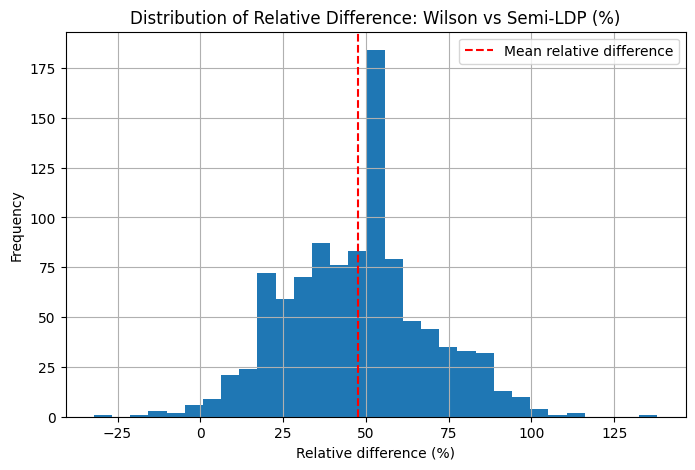

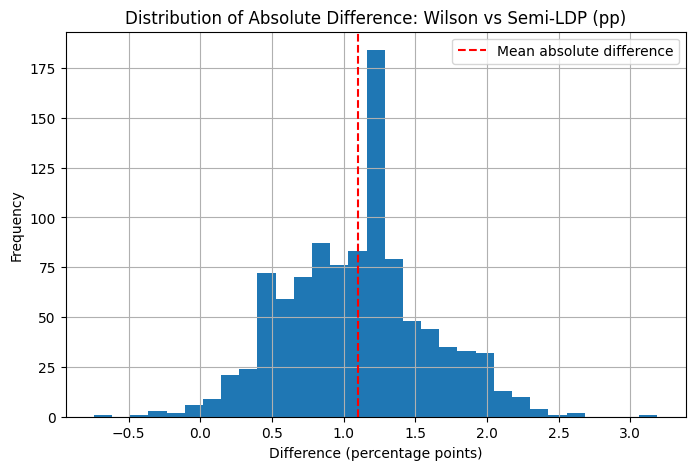

In [ ]:
# ------------------------------------------------------------
# Histogram of relative difference
# ------------------------------------------------------------
diff_rel_wilson = wilson_results_df["wilson_minus_semi_relative_pct"]

plt.figure(figsize=(8,5))
plt.hist(diff_rel_wilson, bins='auto')

plt.axvline(
    diff_rel_wilson.mean(),
    linestyle="--",
    color="red",
    label="Mean relative difference"
)

plt.title("Distribution of Relative Difference: Wilson vs Semi-LDP (%)")
plt.xlabel("Relative difference (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Histogram of absolute difference (percentage points)
# ------------------------------------------------------------
diff_pp_wilson = wilson_results_df["wilson_minus_semi_pp"]

plt.figure(figsize=(8,5))
plt.hist(diff_pp_wilson, bins='auto')

plt.axvline(
    diff_pp_wilson.mean(),
    linestyle="--",
    color="red",
    label="Mean absolute difference"
)

plt.title("Distribution of Absolute Difference: Wilson vs Semi-LDP (pp)")
plt.xlabel("Difference (percentage points)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()


Le **premier graphique**, qui représente la **distribution de l’écart relatif entre la PD de Wilson et la PD empirique du semi-LDP**, montre que la distribution est **très majoritairement située au-dessus de zéro**, avec une **moyenne autour de 45 à 50 %**. Cela signifie qu’en moyenne, la **borne supérieure de Wilson surestime la PD empirique d’environ la moitié de sa valeur**. Ce résultat est cohérent avec ce que l’on observait déjà sur le graphique global : dans le cadre non segmenté, **Wilson est une méthode prudente**, et même sensiblement prudente. La présence de quelques valeurs négatives indique que, pour certains sous-échantillons, la borne supérieure de Wilson peut ponctuellement être inférieure à la PD du semi-LDP, mais ces cas restent minoritaires. L’essentiel de la masse est concentré entre environ **20 % et 80 %**, ce qui confirme que le biais prudentiel est non seulement positif, mais aussi relativement stable.

Le **second histogramme**, qui mesure cette fois l’**écart absolu en points de pourcentage**, complète bien l’analyse. On voit que la distribution est elle aussi **largement positive**, avec une **moyenne proche de 1,1 point de pourcentage**. Autrement dit, la prudence de Wilson, qui peut paraître forte en relatif, correspond en niveau à une augmentation moyenne de l’ordre de **1 point de PD** par rapport à la référence empirique. La majorité des observations semblent se situer entre environ **0,4 et 1,8 point de pourcentage**, ce qui montre que l’ajustement reste significatif mais pas explosif. Là encore, quelques valeurs légèrement négatives apparaissent, mais elles sont rares.

Pris ensemble, ces deux graphiques montrent donc que, dans l’approche **non segmentée**, la méthode de Wilson produit une **surévaluation globalement systématique de la PD**, à la fois en **relatif** et en **absolu**. Le premier histogramme montre que cette prudence est importante proportionnellement au niveau de risque, tandis que le second montre qu’elle reste, en niveau, d’un ordre de grandeur raisonnablement interprétable. En résumé, **Wilson apparaît ici comme une méthode conservatrice, assez stable, et dotée d’un biais prudentiel positif marqué**.


### 5.5 Global summary


In [ ]:
# ------------------------------------------------------------
# Global summary for the three methods
# ------------------------------------------------------------
global_summary = pd.DataFrame({
    "metric": [
        "Empirical PD",
        "Pluto-Tasche PD (95%)",
        "Wilson lower (95%)",
        "Wilson midpoint (95%)",
        "Wilson upper (95%)"
    ],
    "value_pct": [
        pd_semi_emp_pct,
        ldp_results_df["pluto_tasche_pd_95_pct"].mean(),
        wilson_results_df["wilson_lower_95_pct"].mean(),
        wilson_results_df["wilson_mid_95_pct"].mean(),
        wilson_results_df["wilson_upper_95_pct"].mean()
    ]
})

print(global_summary)

                  metric  value_pct
0           Empirical PD   2.310170
1  Pluto-Tasche PD (95%)   3.232258
2     Wilson lower (95%)   1.592490
3  Wilson midpoint (95%)   2.500431
4     Wilson upper (95%)   3.408371


### 5.6 Global method comparison


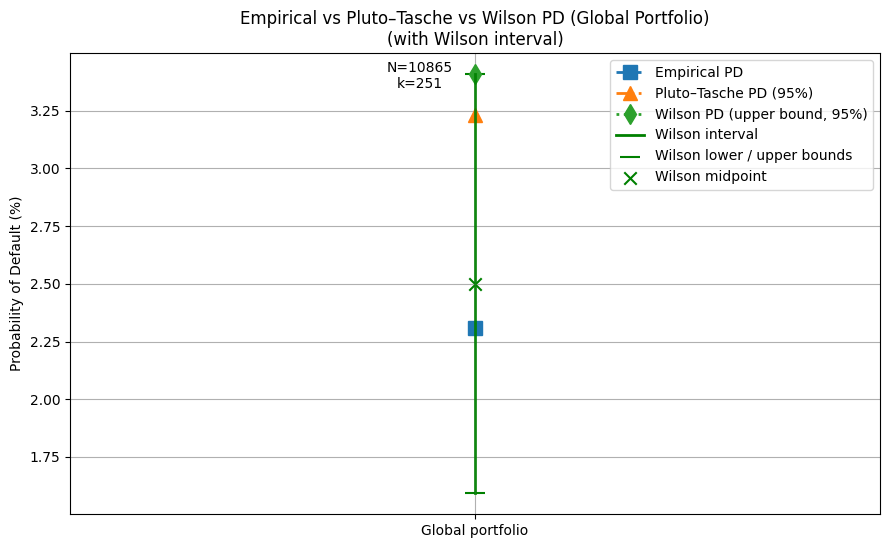

In [ ]:
# ------------------------------------------------------------
# Global comparison plot:
# Empirical PD, Pluto–Tasche, Wilson upper, Wilson interval
# ------------------------------------------------------------
empirical_pd_pct = pd_semi_emp_pct
pluto_tasche_mean_pct = ldp_results_df["pluto_tasche_pd_95_pct"].mean()

wilson_lower_mean_pct = wilson_results_df["wilson_lower_95_pct"].mean()
wilson_mid_mean_pct   = wilson_results_df["wilson_mid_95_pct"].mean()
wilson_upper_mean_pct = wilson_results_df["wilson_upper_95_pct"].mean()

labels = ["Global portfolio"]
x = np.arange(len(labels))

plt.figure(figsize=(9,6))

# Empirical PD
plt.plot(
    x,
    [empirical_pd_pct],
    marker="s",
    markersize=10,
    linestyle="--",
    linewidth=2,
    label="Empirical PD"
)

# Pluto–Tasche PD
plt.plot(
    x,
    [pluto_tasche_mean_pct],
    marker="^",
    markersize=10,
    linestyle="-.",
    linewidth=2,
    label="Pluto–Tasche PD (95%)"
)

# Wilson upper bound
plt.plot(
    x,
    [wilson_upper_mean_pct],
    marker="d",
    markersize=10,
    linestyle=":",
    linewidth=2,
    label="Wilson PD (upper bound, 95%)"
)

# Wilson interval: lower / midpoint / upper
plt.plot(
    [x[0], x[0], x[0]],
    [wilson_lower_mean_pct, wilson_mid_mean_pct, wilson_upper_mean_pct],
    color="green",
    alpha=0.9,
    linewidth=2
)

plt.scatter(x[0], wilson_lower_mean_pct, color="green", marker="_", s=220)
plt.scatter(x[0], wilson_mid_mean_pct,   color="green", marker="x", s=80)
plt.scatter(x[0], wilson_upper_mean_pct, color="green", marker="_", s=220)

# Legend entries for interval
plt.plot([], [], color="green", linewidth=2, label="Wilson interval")
plt.scatter([], [], color="green", marker="_", s=220, label="Wilson lower / upper bounds")
plt.scatter([], [], color="green", marker="x", s=80, label="Wilson midpoint")

# Optional annotation
plt.annotate(
    f"N={N_semi}\nk={k_semi}",
    (x[0], max(pluto_tasche_mean_pct, wilson_upper_mean_pct, empirical_pd_pct)),
    textcoords="offset points",
    xytext=(-40, -10),   # gauche, bas
    ha="center",
    fontsize=10
)

plt.xticks(x, labels)
plt.ylabel("Probability of Default (%)")
plt.title("Empirical vs Pluto–Tasche vs Wilson PD (Global Portfolio)\n(with Wilson interval)")
plt.legend()
plt.grid(True)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Le graphique global permet de comparer, à l’échelle de l’ensemble du portefeuille, la **PD empirique** du semi-LDP, la **PD estimée par Pluto–Tasche**, ainsi que la **méthode de Wilson** à travers sa **borne supérieure**, sa **borne inférieure** et le **centre de l’intervalle**.

Une première observation importante est que la **PD empirique** se situe **strictement au-dessus de la borne inférieure de Wilson**. Ce point est cohérent avec la logique théorique de l’intervalle de Wilson : la borne basse représente une estimation prudente vers le bas, tandis que la PD empirique observée dans le semi-LDP reste ici à l’intérieur de l’intervalle. Cela constitue déjà un premier signal rassurant sur la cohérence statistique de la construction.

On observe ensuite que la **PD empirique**, la **PD Pluto–Tasche** et la **borne supérieure de Wilson** sont toutes contenues dans le **même intervalle de Wilson**. Cette propriété est particulièrement intéressante, car elle montre que l’intervalle de Wilson ne fournit pas seulement une estimation ponctuelle prudente via sa borne supérieure : il donne également une **fourchette de valeurs plausibles** pour la PD du portefeuille. En pratique, cela signifie que l’on dispose ici d’un **intervalle de confiance à 95 %** permettant d’encadrer la variabilité des estimations de PD. Autrement dit, la méthode de Wilson apporte non seulement une estimation conservatrice, mais aussi une **mesure explicite de l’incertitude** autour de cette estimation.

Un autre point important concerne la position relative des différentes méthodes à l’intérieur de cet intervalle. On constate que la **PD Pluto–Tasche** est située dans la partie supérieure de l’intervalle, très proche de la **borne supérieure de Wilson**, ce qui confirme son caractère prudent. La **PD empirique**, quant à elle, se situe plus bas dans l’intervalle, comme attendu puisqu’elle ne comporte aucun ajustement conservateur. Enfin, le **centre de l’intervalle de Wilson** se place entre les deux, au-dessus de la PD empirique mais nettement en dessous de la borne supérieure. Cette organisation est intéressante car elle permet de visualiser immédiatement trois niveaux de lecture :

* la **PD empirique** comme référence centrale observée ;
* le **milieu de Wilson** comme niveau intermédiaire ;
* les estimations **Pluto–Tasche** et **Wilson upper** comme niveaux plus prudents.

D’un point de vue interprétatif, l’intervalle de Wilson enrichit donc fortement l’analyse. Sans lui, on comparerait seulement des estimations ponctuelles, ce qui donne une hiérarchie de prudence mais ne renseigne pas directement sur la **dispersion plausible** autour de la PD. Avec l’intervalle, on obtient une information supplémentaire essentielle : **l’amplitude de l’incertitude statistique** associée au portefeuille. Ici, cette amplitude n’est pas négligeable, ce qui rappelle qu’en contexte de **Low Default Portfolio**, même au niveau global, les estimations de PD restent sensibles au faible nombre relatif de défauts.

En résumé, ce graphique montre que :

* la **borne supérieure de Wilson** reste l’estimation la plus conservatrice ;
* **Pluto–Tasche** est également très prudent et se situe proche du haut de l’intervalle ;
* la **PD empirique** demeure plus basse, mais reste bien contenue dans l’intervalle ;
* et surtout, l’**intervalle de Wilson** fournit une information précieuse sur la **variabilité plausible de la PD**, ce qui en fait non seulement un outil d’estimation prudente, mais aussi un outil d’**encadrement statistique de l’incertitude**.


## 6. Hierarchical extension of Pluto–Tasche


Afin d’améliorer la **robustesse de l’estimation de la PD** au sein de nos **Low Default Portfolio (LDP)**, nous étendons le cadre **Pluto–Tasche** en introduisant une **segmentation des portefeuilles**. Plutôt que d’estimer une PD unique pour l’ensemble du portefeuille, nous divisons les LDP en **segments homogènes de risque**.

Cette segmentation permet de capter les **différences structurelles de risque de crédit** entre profils d’emprunteurs. Toutefois, le **niveau de granularité** doit être choisi avec précaution. Si les segments sont trop fins, le **nombre d’observations** par segment devient insuffisant, entraînant des **estimations instables** et un risque de **sur-ajustement**. À l’inverse, des segments trop larges peuvent ignorer l’**hétérogénéité du risque**, conduisant à un **sous-ajustement** et à une perte de pouvoir discriminant.

L’objectif est donc de trouver un **équilibre entre stabilité statistique et sensibilité au risque**. L’**extension hiérarchique** de la méthodologie Pluto–Tasche est particulièrement adaptée à ce contexte, car elle permet d’estimer des **PD par segment** tout en mutualisant l’information du portefeuille global via une **distribution a priori commune**. Cette approche garantit des **estimations robustes et prudentes**, même dans les segments présentant un **faible nombre de défauts**.

Nous procéderons de la sorte:

1. Le **portefeuille semi-LDP** est tout d’abord **segmenté** selon un ou plusieurs **critères jugés économiquement pertinents**.

2. Le **taux de défaut** est ensuite calculé pour **chaque segment** du **semi-LDP**. Compte tenu de la **taille importante** de ce portefeuille, ces **estimations empiriques** sont considérées comme des **références fiables** pour la **probabilité de défaut par segment**, en vertu de la **loi des grands nombres**.

3. Les véritables **portefeuilles LDP** obtenus par **échantillonnage aléatoire** sont ensuite **segmentés selon les mêmes critères**, afin d’assurer la **cohérence de la comparaison**.

4. La **méthode de Pluto–Tasche hiérarchique** est appliquée à chaque **LDP segmenté** afin d’estimer les **probabilités de défaut par segment** dans un **contexte de faible nombre de défauts**.

5. Les **probabilités de défaut** obtenues pour **chaque segment** des **LDP** sont enfin comparées aux **probabilités de défaut de référence** issues du **semi-LDP**.


Pour des raisons de **simplicité** et d’**interprétabilité**, la **segmentation** sera étudiée sur **variables qualitatives** plutôt que **quantitatives**, ces dernières nécessitant des **regroupements préalables** qui alourdiront inutilement notre **analyse**. Si toutefois le lecteur souhaiterait explorer les segmentations quantitatives, nous lui conseillons de réaliser des buckets par quantiles puis de flager chaque observation du semi-LDP suivant le bucket auquel elle appartient puis enfin de segmenter le semi-LDP suivant ces flags.

In [ ]:
qualitative_cols = semi_ldp.select_dtypes(include=["object", "string"]).columns

print("Qualitative columns:\n")

for col in qualitative_cols:
    print(col)

Qualitative columns:

term
grade
sub_grade
emp_title
emp_length
home_ownership
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
delinq_2yrs
earliest_cr_line
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
application_type
acc_now_delinq
tot_cur_bal
total_rev_hi_lim


In [ ]:
for col in qualitative_cols:
    values = semi_ldp[col].dropna().unique()

    if len(values) < 100:
        print(f"\nColumn: {col}")
        print(f"Number of distinct values: {len(values)}")
        print(sorted(values))
        print("-" * 50)

Compte tenu de la **structure du portefeuille semi-LDP** (10 865 observations et 251 défauts), la **stratégie de segmentation** peut être conçue avec davantage de flexibilité que dans le cadre du LDP final. Le portefeuille reste **faiblement risqué** (taux de défaut de 2,31 %), tout en contenant un **nombre de défauts suffisant** pour garantir des **estimations empiriques statistiquement stables**.

La segmentation doit néanmoins respecter trois principes fondamentaux : **pertinence économique**, **fiabilité statistique** (nombre suffisant d’observations par segment) et **absence de biais d’information** (exclusion des variables postérieures à l’octroi).

Dans ce contexte, **sub_grade** constitue la **variable de segmentation primaire** la plus appropriée. Elle reflète l’**évaluation interne du risque** réalisée par LendingClub et propose dix catégories ordonnées (A1 à B5), formant une **hiérarchie cohérente du risque**. Compte tenu de la taille de l’échantillon, cette granularité reste **statistiquement maîtrisable**, avec un nombre attendu de défauts suffisant par sous-grade.

Attention, la variable **home_ownership** n’est pas retenue comme axe de segmentation dans l’**analyse hiérarchique**. En effet, elle a déjà été utilisée comme **critère de filtrage** lors de la construction du **semi-LDP**, restreignant l’échantillon aux profils considérés comme **financièrement plus stables** (*OWN* et *MORTGAGE*). Cette **sélection préalable** réduit fortement l’**hétérogénéité du risque** sur cette dimension et limite son **pouvoir discriminant**. La **re-segmentation** selon ce critère serait donc **redondante** et n’apporterait pas d’**information supplémentaire pertinente**.

Dans le cas de données encore plus riches et si **sub_grade** ne fournirait pas un niveau de segmentation suffisant, un second niveau d’affinement pourrait être envisager avec des variables telles que **verification_status**, une version regroupée de **emp_length**, ou des indicateurs dérivés de **delinq_2yrs** et **inq_last_6mths** sont **économiquement justifiées** et **statistiquement exploitables**. Elles captent la **stabilité de l’emprunteur** et son **comportement de crédit** sans introduire de biais prospectif. Une **segmentation croisée** (par exemple sub_grade × verification_status) peut être envisagée si chaque segment conserve une taille suffisante. Compte tenu d’un **échantillon de 10 000 observations**, le **premier critère** conduit à environ **1 000 observations par segment**. Afin de respecter les conditions assurant la **validité asymptotique (loi des grands nombres)** et de maintenir la **robustesse statistique**, **aucun second critère de segmentation** n’est introduit. Des **éléments complémentaires** sont néanmoins précisés en note pour le lecteur intéressé.

En revanche, les variables liées à la **performance ex post du prêt** (loan_status, montants de recouvrement, pénalités, dates de paiement) doivent être exclues afin d’éviter un **biais d’information**. De même, des variables très fines comme **addr_state** ou les dates brutes ne devraient être utilisées qu’après agrégation pour éviter une **fragmentation excessive**.

Globalement, le semi-LDP autorise une **segmentation plus riche**, mais celle-ci doit rester **parcimonieuse et économiquement justifiée**, afin de préserver un **équilibre robuste entre finesse du modèle et stabilité statistique**, en évitant à la fois le **sur-ajustement** et le **sous-ajustement**.


---

# **Note sur la segmentation de deuxième niveau**

Il existe un **point de confusion fréquent**. L’objectif n’est pas de **re-segmenter chaque segment indépendamment**, mais de construire une **structure de segmentation hiérarchique cohérente**.

Nous ne procédons pas de la manière suivante :

A1 → puis A1 × verification
A2 → puis A2 × verification
et ainsi de suite indépendamment.

À l’inverse, nous construisons une **grille de segmentation unifiée**, où le segment final est défini comme :

**Segment final = sub_grade × variable additionnelle**

En pratique, le premier niveau de segmentation repose sur :

**sub_grade ∈ {A1, A2, A3, A4, A5, B1...}**

Cela conduit à **10 segments primaires**.

Au second niveau, la segmentation peut être affinée à l’aide d’une **variable économiquement pertinente**, par exemple :

**verification_status ∈ {Not Verified, Source Verified, Verified}**

Les segments résultants deviennent alors des combinaisons telles que :

(A1, Verified)
(A1, Not Verified)
(A1, Source Verified)
(A2, Verified)
(A2, Not Verified)
etc.

Mathématiquement :

**Nombre de segments = 10 × 3 = 30**
(hors cellules éventuellement vides).

Cette approche est justifiée car **sub_grade capte le niveau structurel du risque de crédit**, tandis que **verification_status reflète la qualité et la fiabilité de l’information emprunteur**. Ensemble, elles permettent une **segmentation plus fine et économiquement cohérente**.

Cependant, la **prudence est essentielle**. Avec seulement **10 000 observations** restantes dans le portefeuille filtré, une **segmentation croisée excessive** peut rapidement produire des groupes très petits. Par exemple, combiner 10 sous-grades, 3 statuts de vérification et 2 catégories de home ownership générerait jusqu’à **60 segments**! Cela réintroduirait un **problème de petits échantillons**, conduisant à des **estimations de PD instables** et à une **variance statistique excessive**.

Une stratégie prudente consiste donc à :

- **Option A** : segmenter uniquement par **sub_grade** (4 segments stables).
- **Option B** : segmenter par **sub_grade × une variable additionnelle**, en veillant à ce que chaque segment contienne un nombre suffisant d'observations pour rester dans le cadre d'application de la loi des grands nombres.

Sinon, la **variance augmente fortement**, les **ajustements Pluto–Tasche deviennent extrêmes**, et le **shrinkage hiérarchique domine l’estimation**.

Le point conceptuel clé est que la segmentation ne consiste pas à diviser le portefeuille autant que possible. Elle consiste à segmenter **uniquement lorsque la variable supplémentaire apporte une information économique réelle** et que **les données restent suffisantes pour garantir la robustesse statistique**.

En résumé, si le lecteur n'obtient pas une segmentation satifaisante avec le critère primaire, (par exemple avec **sub_grade**) et, si cela est justifié, il pourra d'abord croiser avec **une seule variable pertinente supplémentaire** puis il devra porter beaucoup d'attention à ce que chaque sous-segment contienne suffisamment d'observations avant d'ajouter de nouveaux critères. Le lecteur devra éviter de multiplier inutilement les intersections et de créer de nombreux segments petits et instables. Cette approche disciplinée préserve à la fois la **cohérence économique** et la **fiabilité statistique**, ce qui est essentiel dans un cadre de **Low Default Portfolio**.


### 6.1 Rating-segment benchmark


In [ ]:
# Available sub_grades in the LDP
print("Sub-grades in semi-LDP :", sorted(semi_ldp["sub_grade"].dropna().unique()))

Sub-grades in semi-LDP : ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5']


In [ ]:
seg_table = (
    semi_ldp.groupby("sub_grade")["default_flag"]
    .agg(N="count", k="sum")
    .reset_index()
    .sort_values("sub_grade")
)

print(seg_table)

  sub_grade     N   k
0        A1  2044  26
1        A2  1579  25
2        A3  1628  25
3        A4  2053  56
4        A5  1889  65
5        B1  1125  37
6        B2   517  14
7        B3    15   0
8        B4    14   3
9        B5     1   0


Les **segments B3, B4 et B5** présentent une **taille d’échantillon insuffisante** pour permettre une **estimation fiable**, même dans un **cadre hiérarchique**. Ils seront donc **regroupés avec B2** afin de garantir la **stabilité des estimations** et d’éviter une **variance excessive**.

In [ ]:
# Create a new risk segment variable
semi_ldp["risk_segment"] = semi_ldp["sub_grade"]

# Merge B2, B3, B4 and B5 into a single segment "B2-B5"
mask_b2_to_b5 = semi_ldp["sub_grade"].isin(["B2", "B3", "B4", "B5"])
semi_ldp.loc[mask_b2_to_b5, "risk_segment"] = "B2-B5"

# B1 remains distinct
# A1 to A5 remain distinct

segmentation_summary = (
    semi_ldp
    .groupby("risk_segment")["default_flag"]
    .agg(N="count", k="sum")
    .reset_index()
)

# Optional: clean ordering
order = ["A1", "A2", "A3", "A4", "A5", "B1", "B2-B5"]
segmentation_summary["risk_segment"] = pd.Categorical(
    segmentation_summary["risk_segment"],
    categories=order,
    ordered=True
)

segmentation_summary = segmentation_summary.sort_values("risk_segment")

print(segmentation_summary)

  risk_segment     N   k
0           A1  2044  26
1           A2  1579  25
2           A3  1628  25
3           A4  2053  56
4           A5  1889  65
5           B1  1125  37
6        B2-B5   547  17


Le recours au **shrinkage hiérarchique** est justifié par l’**hétérogénéité des tailles d’échantillon** entre **segments**, en particulier pour le **segment B2–B5** **(N = 547)**.

In [ ]:
# Build segmentation summary with default rate

segmentation_df = (
    semi_ldp
    .groupby("risk_segment")["default_flag"]
    .agg(
        n_observations="count",
        n_defaults="sum"
    )
    .reset_index()
)

# Compute default rate
segmentation_df["default_rate"] = (
    segmentation_df["n_defaults"] / segmentation_df["n_observations"]
)

# Sort by risk hierarchy
segmentation_df = segmentation_df.sort_values("risk_segment")

segmentation_df["default_rate_pct"] = segmentation_df["default_rate"] * 100

print(segmentation_df)

  risk_segment  n_observations  n_defaults  default_rate  default_rate_pct
0           A1            2044          26      0.012720          1.272016
1           A2            1579          25      0.015833          1.583281
2           A3            1628          25      0.015356          1.535627
3           A4            2053          56      0.027277          2.727716
4           A5            1889          65      0.034410          3.440974
5           B1            1125          37      0.032889          3.288889
6        B2-B5             547          17      0.031079          3.107861


Maintenant que nous avons nos **“vraies” estimations de la PD par segment**, nous allons **échantillonner notre semi-LDP**, conserver les **échantillons comportant moins de 20 défauts**, puis estimer la **probabilité de défaut intra-segment** via la **méthode de Pluto–Tasche généralisée**.


### 6.2 LDP sampling


In [ ]:
# -----------------------------
# Parameters
# -----------------------------
sample_fraction = 0.10
n_samples = 1000
alpha_conf = 0.95
random_seed = 31

np.random.seed(random_seed)

segments = ["A1","A2","A3","A4","A5","B1","B2-B5"]

ldp_samples = []
ldp_ids = []

for i in range(n_samples):

    sample_i = semi_ldp.sample(frac=sample_fraction, replace=False)
    # k_total = sample_i["default_flag"].sum()

    # if k_total < 20:

    ldp_samples.append(sample_i)
    ldp_ids.append(i)

print("Number of LDP samples kept:", len(ldp_samples))

Number of LDP samples kept: 1000


### 6.3 Hierarchical estimator


In [ ]:
def hierarchical_pluto_tasche(sample_df, segments, alpha_conf=0.95):

    # Compute N_j and k_j per segment
    summary = (
        sample_df
        .groupby("risk_segment")["default_flag"]
        .agg(N="count", k="sum")
        .reindex(segments)
        .fillna(0)
    )

    N = summary["N"].values.astype(float)
    k = summary["k"].values.astype(float)

    # Remove empty segments
    mask = N > 0
    N = N[mask]
    k = k[mask]
    active_segments = np.array(segments)[mask]

    # -----------------------------
    # Estimate alpha, beta (MLE)
    # -----------------------------
    def neg_loglik(log_params):
        log_alpha, log_beta = log_params
        alpha = np.exp(log_alpha)
        beta_param = np.exp(log_beta)

        ll = np.sum(
            betaln(alpha + k, beta_param + (N - k))
            - betaln(alpha, beta_param)
        )
        return -ll

    x0 = np.log([1.0, 1.0])
    res = minimize(neg_loglik, x0=x0, method="L-BFGS-B")

    alpha_hat = float(np.exp(res.x[0]))
    beta_hat  = float(np.exp(res.x[1]))

    # Posterior parameters
    a_post = alpha_hat + k
    b_post = beta_hat + (N - k)

    PD_95 = beta.ppf(alpha_conf, a_post, b_post)

    result = pd.DataFrame({
        "segment": active_segments,
        "N_segment": N.astype(int),
        "k_segment": k.astype(int),
        "PD_hierarchical_95": PD_95
    })

    return result

### 6.4 Estimation across sampled portfolios


In [ ]:
bad_ids = []

all_results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    warnings.simplefilter("ignore", category=OptimizeWarning)

    for idx, sample_df in enumerate(ldp_samples):
        result_df = hierarchical_pluto_tasche(sample_df, segments, alpha_conf=alpha_conf)

        # sanity check
        if result_df[["PD_hierarchical_95"]].isna().any().any():
            bad_ids.append(idx) # In case of failure

        result_df["ldp_id"] = idx
        result_df["total_defaults_semi_ldp"] = int(sample_df["default_flag"].sum())
        all_results.append(result_df)

final_results = pd.concat(all_results, ignore_index=True)

print("Number of LDP samples with NaN PD_hierarchical_95:", len(bad_ids))
print("Bad sample ids (first 20):", bad_ids[:20])

Number of LDP samples with NaN PD_hierarchical_95: 0
Bad sample ids (first 20): []


In [ ]:
print(final_results.head(12))

   segment  N_segment  k_segment  PD_hierarchical_95  ldp_id  \
0       A1        207          1            0.029741       0   
1       A2        136          3            0.032300       0   
2       A3        168          4            0.032351       0   
3       A4        205          5            0.032308       0   
4       A5        199          7            0.033684       0   
5       B1        112          5            0.034096       0   
6    B2-B5         59          3            0.033829       0   
7       A1        229          3            0.023693       1   
8       A2        160          4            0.023712       1   
9       A3        153          4            0.023714       1   
10      A4        220          5            0.023709       1   
11      A5        168          5            0.023718       1   

    total_defaults_semi_ldp  
0                        28  
1                        28  
2                        28  
3                        28  
4                

### 6.5 Merge with empirical benchmark


In [ ]:
# ------------------------------------------------------------
# Merge with semi-LDP benchmark PD
# ------------------------------------------------------------
semi_pd_dict = dict(zip(segmentation_df["risk_segment"],
                        segmentation_df["default_rate"]))

final_results["PD_semi_ldp"] = final_results["segment"].map(semi_pd_dict)

# ------------------------------------------------------------
# Absolute difference (in level)
# ------------------------------------------------------------
final_results["difference_vs_semi"] = (
    final_results["PD_hierarchical_95"]
    - final_results["PD_semi_ldp"]
)

# ------------------------------------------------------------
# Relative difference (in %)
# ------------------------------------------------------------
final_results["relative_difference_pct"] = (
    final_results["difference_vs_semi"]
    / final_results["PD_semi_ldp"]
) * 100

print(final_results.head(12))

   segment  N_segment  k_segment  PD_hierarchical_95  ldp_id  \
0       A1        207          1            0.029741       0   
1       A2        136          3            0.032300       0   
2       A3        168          4            0.032351       0   
3       A4        205          5            0.032308       0   
4       A5        199          7            0.033684       0   
5       B1        112          5            0.034096       0   
6    B2-B5         59          3            0.033829       0   
7       A1        229          3            0.023693       1   
8       A2        160          4            0.023712       1   
9       A3        153          4            0.023714       1   
10      A4        220          5            0.023709       1   
11      A5        168          5            0.023718       1   

    total_defaults_semi_ldp  PD_semi_ldp  difference_vs_semi  \
0                        28     0.012720            0.017021   
1                        28     0.01583

### 6.6 Mean PD by rating segment


  segment  PD_hier_mean   PD_semi  n_observations  n_defaults
0      A1      0.028313  0.012720            2044          26
1      A2      0.030214  0.015833            1579          25
2      A3      0.030011  0.015356            1628          25
3      A4      0.034397  0.027277            2053          56
4      A5      0.037844  0.034410            1889          65
5      B1      0.037335  0.032889            1125          37
6   B2-B5      0.036462  0.031079             547          17


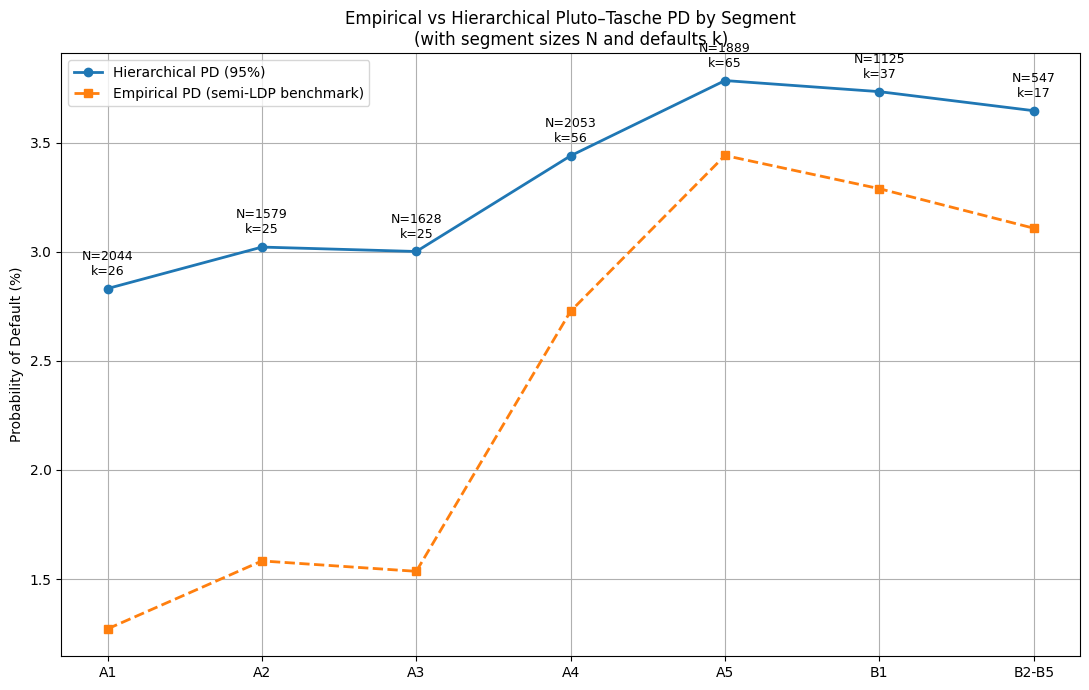

In [ ]:
# --- Compute mean PD per segment across all LDP samples ---
plot_df = (
    final_results
    .groupby("segment")
    .agg(
        PD_hier_mean=("PD_hierarchical_95", "mean"),
        PD_semi=("PD_semi_ldp", "mean")
    )
    .reset_index()
    .sort_values("segment")
)

# --- Add N_j and k_j from segmentation_df (semi-LDP reference) ---
plot_df = (
    plot_df
    .merge(
        segmentation_df[["risk_segment", "n_observations", "n_defaults"]],
        left_on="segment",
        right_on="risk_segment",
        how="left"
    )
    .drop(columns=["risk_segment"])
)

print(plot_df)

segments = plot_df["segment"].values
x = np.arange(len(segments))

plt.figure(figsize=(11,7))

# Hierarchical Pluto–Tasche PD (95% quantile, averaged across samples)
plt.plot(
    x, plot_df["PD_hier_mean"] * 100,
    marker="o", linewidth=2,
    label="Hierarchical PD (95%)"
)

# Semi-LDP benchmark (empirical rate in reference semi-LDP)
plt.plot(
    x, plot_df["PD_semi"] * 100,
    marker="s", linestyle="--", linewidth=2,
    label="Empirical PD (semi-LDP benchmark)"
)

# --- Add N_j and k_j annotations above each segment ---
for i, row in plot_df.iterrows():
    plt.annotate(
        f"N={int(row['n_observations'])}\nk={int(row['n_defaults'])}",
        (x[i], max(row["PD_hier_mean"], row["PD_semi"]) * 100),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

plt.xticks(x, segments)
plt.ylabel("Probability of Default (%)")
plt.title("Empirical vs Hierarchical Pluto–Tasche PD by Segment\n(with segment sizes N and defaults k)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Le graphique ci-dessus compare la **probabilité de défaut empirique** observée dans le **semi-LDP de référence** avec la **PD estimée à l’aide du modèle hiérarchique de Pluto–Tasche** pour chacun des segments de rating. Les annotations indiquent pour chaque segment la **taille du portefeuille ($N$)** et le **nombre de défauts observés ($k$)**.

On observe tout d’abord que les **estimations issues du modèle hiérarchique sont systématiquement supérieures à la PD empirique** pour l’ensemble des segments. Cela reflète le **caractère prudent de la méthode Pluto–Tasche**, qui repose sur l’utilisation d’un **quantile élevé de la distribution Beta** afin d’obtenir une estimation conservatrice de la probabilité de défaut. Cette propriété est particulièrement recherchée dans le contexte réglementaire des **Low Default Portfolios (LDP)**.

Un second résultat important concerne la **forme de la courbe estimée**. La PD issue du modèle hiérarchique apparaît **nettement plus lisse et plus régulière** que la PD empirique. Cette différence provient du mécanisme de **shrinkage introduit par l’approche hiérarchique** : les estimations par segment ne dépendent pas uniquement des observations locales $(k,N)$, mais sont également **informées par l’ensemble du portefeuille via le prior global**. Ce mécanisme permet de **réduire la variabilité statistique des estimations**, en particulier pour les segments présentant un nombre relativement faible d’observations ou de défauts.

À l’inverse, la **PD empirique** reflète directement les **fluctuations d’échantillonnage propres à chaque segment**, ce qui explique les variations plus irrégulières observées sur la courbe orange. L’approche hiérarchique agit donc comme un **mécanisme de régularisation**, produisant une structure de PD plus stable et plus cohérente entre les segments, compensant ainsi le manque d'information sur les sub-grades les plus risqués.

Ces résultats constituent un **signal très positif pour l’utilisation du modèle hiérarchique dans un contexte LDP**. En effet, la méthode parvient simultanément à produire des **estimations prudentes**, tout en **lissant les variations excessives dues au bruit statistique**, ce qui améliore la **robustesse globale de la courbe de PD estimée**.


### 6.7 Hierarchical-model bias diagnostics


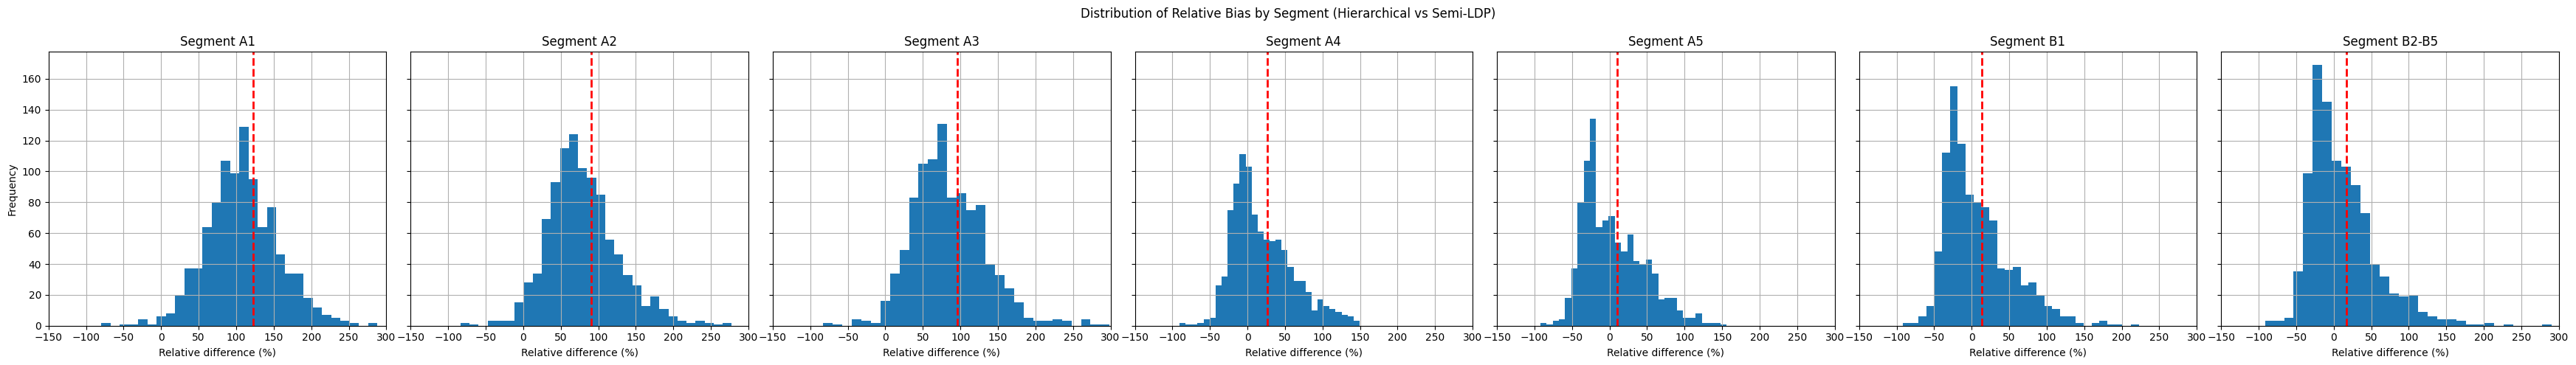

In [ ]:
# ------------------------------------------------------------
# Compute relative difference in %
# ( (Hierarchical - Semi) / Semi ) * 100
# ------------------------------------------------------------
final_results["diff_relative_pct"] = (
    (final_results["PD_hierarchical_95"] - final_results["PD_semi_ldp"])
    / final_results["PD_semi_ldp"]
) * 100

# ------------------------------------------------------------
# Define zoom range
# ------------------------------------------------------------
lower_bound = -150
upper_bound = 300

# ------------------------------------------------------------
# Get segments
# ------------------------------------------------------------
segments = sorted(final_results["segment"].unique())

# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------
n_segments = len(segments)
fig, axes = plt.subplots(1, n_segments, figsize=(5*n_segments,5), sharey=True)

# If only one segment, axes is not iterable
if n_segments == 1:
    axes = [axes]

# ------------------------------------------------------------
# Plot histogram for each segment
# ------------------------------------------------------------
for ax, seg in zip(axes, segments):

    data = final_results[final_results["segment"] == seg]["diff_relative_pct"]

    zoomed_data = data[(data >= lower_bound) & (data <= upper_bound)]

    ax.hist(zoomed_data, bins=30)

    ax.axvline(
        data.mean(),
        color='red',
        linestyle="--",
        linewidth=2)

    ax.set_title(f"Segment {seg}")
    ax.set_xlabel("Relative difference (%)")
    ax.grid(True)
    ax.set_xlim(lower_bound, upper_bound)

axes[0].set_ylabel("Frequency")

plt.suptitle("Distribution of Relative Bias by Segment (Hierarchical vs Semi-LDP)")
plt.tight_layout()

plt.show()

### **Segment A1**

La distribution est **très majoritairement positive** et centrée autour d’un écart relatif élevé. Cela signifie que, pour **A1**, la **PD hiérarchique est presque toujours supérieure à la PD empirique**, ce qui est cohérent avec un segment très sûr pour lequel le modèle applique une **correction prudentielle à la hausse**.

### **Segment A2**

On observe également une distribution **largement positive**, avec une moyenne un peu plus faible que pour A1 mais restant nettement au-dessus de zéro. Le modèle hiérarchique demeure donc **clairement prudent** sur ce segment, tout en introduisant un lissage moins extrême que pour A1.

### **Segment A3**

La logique reste la même : la distribution est globalement **positive** et assez étalée, ce qui indique que la **PD hiérarchique dépasse généralement la PD empirique**. Le segment A3 reste donc dans la zone où l’approche hiérarchique agit principalement comme un **ajustement prudent à la hausse**.

### **Segment A4**

Ici, la distribution se recentre davantage autour de zéro, avec à la fois des valeurs positives et négatives. Cela traduit un **segment intermédiaire**, pour lequel le modèle hiérarchique n’augmente plus systématiquement la PD : il commence à jouer un rôle plus équilibré entre **prudence** et **shrinkage**.

### **Segment A5**

La distribution devient davantage orientée vers les **valeurs négatives ou faiblement positives**. Cela signifie que, sur **A5**, la **PD hiérarchique est souvent inférieure à la PD empirique**, ce qui reflète l’effet de **rétraction vers la moyenne globale** sur un segment déjà plus risqué.

### **Segment B1**

Le phénomène observé sur A5 se confirme : la distribution est centrée près de zéro mais avec une masse importante du côté négatif. Le modèle hiérarchique tend donc ici à **corriger à la baisse les PD empiriques les plus élevées**, en limitant les excès dus à la variabilité locale.

### **Segment B2-B5**

La distribution est également concentrée autour de zéro avec une asymétrie à droite, mais la moyenne reste modérée. Cela suggère que, pour ce segment plus petit et plus instable, le modèle hiérarchique exerce surtout un **effet de stabilisation**, en évitant à la fois les sous-estimations trop optimistes et les surestimations trop extrêmes.


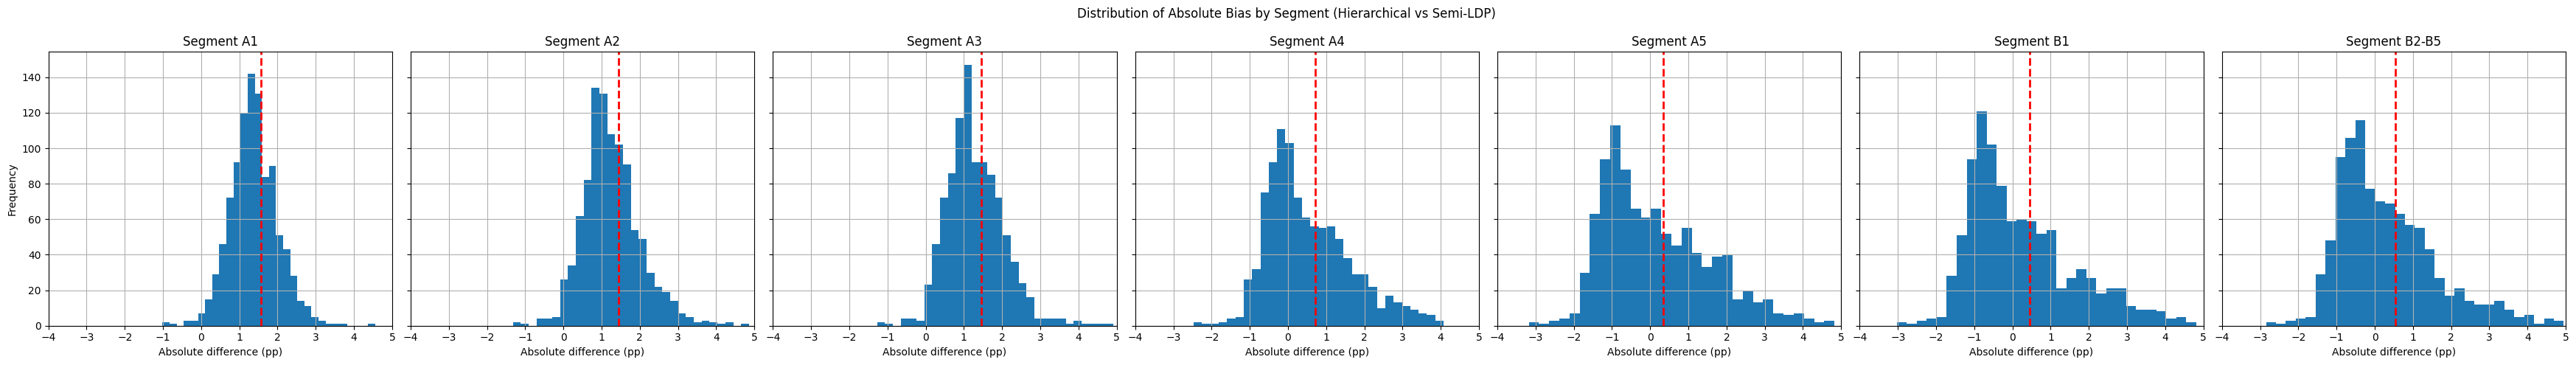

In [ ]:
# ------------------------------------------------------------
# Compute absolute difference in percentage points
# (Hierarchical - Semi) * 100
# ------------------------------------------------------------
final_results["diff_absolute_pp"] = (
    final_results["PD_hierarchical_95"]
    - final_results["PD_semi_ldp"]
) * 100  # percentage points

# ------------------------------------------------------------
# Define zoom range
# ------------------------------------------------------------
lower_bound = -4
upper_bound = 5

# ------------------------------------------------------------
# Get segments
# ------------------------------------------------------------
segments = sorted(final_results["segment"].unique())

# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------
n_segments = len(segments)
fig, axes = plt.subplots(1, n_segments, figsize=(5*n_segments, 5), sharey=True)

# If only one segment, axes is not iterable
if n_segments == 1:
    axes = [axes]

# ------------------------------------------------------------
# Plot histogram for each segment
# ------------------------------------------------------------
for ax, seg in zip(axes, segments):

    data = final_results[final_results["segment"] == seg]["diff_absolute_pp"]

    zoomed_data = data[(data >= lower_bound) & (data <= upper_bound)]

    ax.hist(zoomed_data, bins=30)

    ax.axvline(
        data.mean(),
        color='red',
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Segment {seg}")
    ax.set_xlabel("Absolute difference (pp)")
    ax.grid(True)
    ax.set_xlim(lower_bound, upper_bound)

axes[0].set_ylabel("Frequency")

plt.suptitle("Distribution of Absolute Bias by Segment (Hierarchical vs Semi-LDP)")
plt.tight_layout()

plt.show()

### **Segment A1**

La distribution est **très nettement positive**. La PD hiérarchique est donc **presque toujours supérieure** à la PD empirique, avec une **correction prudente importante**.

### **Segment A2**

Même constat : la distribution est **largement centrée sur la partie positive**. Le modèle hiérarchique applique ici aussi une **sur-correction prudente** en niveau.

### **Segment A3**

La distribution reste **majoritairement positive** et assez concentrée. La PD hiérarchique est donc **régulièrement au-dessus** de l’empirique, de façon assez stable.

### **Segment A4**

La distribution est encore **positive en moyenne**, mais plus étalée. Cela traduit un segment de transition, où la correction hiérarchique reste **globalement à la hausse**, mais de façon moins marquée.

### **Segment A5**

La distribution devient **plus asymétrique** et comporte une masse importante près de zéro et en négatif, mais la **moyenne reste légèrement positive**. En moyenne, la PD hiérarchique reste donc **au-dessus** de l’empirique, même si les ajustements sont plus hétérogènes.

### **Segment B1**

La distribution est également **très dispersée**, avec beaucoup de valeurs négatives mais aussi une queue droite marquée. La **moyenne positive** indique que, globalement, la PD hiérarchique demeure **légèrement plus élevée** que l’empirique.

### **Segment B2-B5**

La distribution est la plus instable, avec une forte dispersion, mais la **moyenne reste positive**. Le modèle hiérarchique conserve donc en moyenne un **biais prudentiel à la hausse**, malgré une variabilité importante sur ce segment plus petit.

Ces résultats sont cohérents avec le graphique comparatif des PD hiérarchiques et empiriques présenté précédemment.

## 7. Classical Pluto–Tasche by segment


### 7.1 Segment-level estimator


In [ ]:
# ------------------------------------------------------------
# Classical Pluto–Tasche prudent PD (segment by segment)
# ------------------------------------------------------------
def pluto_tasche_pd_upper(N: int, k: int, alpha: float = 0.95) -> float:
    if N <= 0:
        return np.nan
    if (k < 0) or (k > N):
        return np.nan
    if (alpha <= 0) or (alpha >= 1):
        return np.nan

    # Closed-form case k = 0
    if k == 0:
        return 1.0 - ((1.0 - alpha) ** (1.0 / N))

    # General case
    a = k + 1
    b = N - k
    return float(beta.ppf(alpha, a, b))


# ------------------------------------------------------------
# Apply classical Pluto–Tasche segment by segment
# ------------------------------------------------------------
all_results_classic = []

for idx, sample_df in enumerate(ldp_samples):

    summary = (
        sample_df
        .groupby("risk_segment")["default_flag"]
        .agg(N="count", k="sum")
        .reindex(segments)
    )

    result_rows = []

    for seg in segments:
        N_seg = summary.loc[seg, "N"]
        k_seg = summary.loc[seg, "k"]

        if pd.isna(N_seg) or pd.isna(k_seg):
            N_seg = 0
            k_seg = 0

        N_seg = int(N_seg)
        k_seg = int(k_seg)

        pd_pt_classic = pluto_tasche_pd_upper(N=N_seg, k=k_seg, alpha=alpha_conf)

        result_rows.append({
            "ldp_id": idx,
            "segment": seg,
            "N_segment": N_seg,
            "k_segment": k_seg,
            "PD_classic_95": pd_pt_classic
        })

    result_df = pd.DataFrame(result_rows)
    result_df["total_defaults_sample"] = int(sample_df["default_flag"].sum())

    all_results_classic.append(result_df)

final_results_classic = pd.concat(all_results_classic, ignore_index=True)

print(final_results_classic.head(12))
print("Number of rows in classical PT results:", len(final_results_classic))

    ldp_id segment  N_segment  k_segment  PD_classic_95  total_defaults_sample
0        0      A1        207          1       0.022711                     28
1        0      A2        136          3       0.056023                     28
2        0      A3        168          4       0.053654                     28
3        0      A4        205          5       0.050596                     28
4        0      A5        199          7       0.065053                     28
5        0      B1        112          5       0.091571                     28
6        0   B2-B5         59          3       0.126207                     28
7        1      A1        229          3       0.033509                     25
8        1      A2        160          4       0.056293                     25
9        1      A3        153          4       0.058825                     25
10       1      A4        220          5       0.047190                     25
11       1      A5        168          5       0.061

# **Merge avec la PD empirique benchmark + calcul des écarts**

In [ ]:
# ------------------------------------------------------------
# Merge benchmark empirical PD from semi-LDP
# ------------------------------------------------------------
semi_pd_dict = dict(zip(segmentation_df["risk_segment"], segmentation_df["default_rate"]))

final_results_classic["PD_semi_ldp"] = final_results_classic["segment"].map(semi_pd_dict)

# ------------------------------------------------------------
# Absolute difference (in level)
# ------------------------------------------------------------
final_results_classic["difference_vs_semi"] = (
    final_results_classic["PD_classic_95"]
    - final_results_classic["PD_semi_ldp"]
)

# ------------------------------------------------------------
# Relative difference (in %)
# ------------------------------------------------------------
final_results_classic["relative_difference_pct"] = (
    final_results_classic["difference_vs_semi"]
    / final_results_classic["PD_semi_ldp"]
) * 100

# ------------------------------------------------------------
# Absolute difference in percentage points
# ------------------------------------------------------------
final_results_classic["diff_absolute_pp"] = (
    final_results_classic["PD_classic_95"]
    - final_results_classic["PD_semi_ldp"]
) * 100

print(final_results_classic.head(12))

    ldp_id segment  N_segment  k_segment  PD_classic_95  \
0        0      A1        207          1       0.022711   
1        0      A2        136          3       0.056023   
2        0      A3        168          4       0.053654   
3        0      A4        205          5       0.050596   
4        0      A5        199          7       0.065053   
5        0      B1        112          5       0.091571   
6        0   B2-B5         59          3       0.126207   
7        1      A1        229          3       0.033509   
8        1      A2        160          4       0.056293   
9        1      A3        153          4       0.058825   
10       1      A4        220          5       0.047190   
11       1      A5        168          5       0.061555   

    total_defaults_sample  PD_semi_ldp  difference_vs_semi  \
0                      28     0.012720            0.009991   
1                      28     0.015833            0.040190   
2                      28     0.015356        

### 7.2 Segment-level comparison


  segment  n_observations  n_defaults   PD_semi  PD_hier_mean  PD_classic_mean
0      A1            2044          26  0.012720      0.028313         0.034879
1      A2            1579          25  0.015833      0.030214         0.043721
2      A3            1628          25  0.015356      0.030011         0.042690
3      A4            2053          56  0.027277      0.034397         0.053990
4      A5            1889          65  0.034410      0.037844         0.065167
5      B1            1125          37  0.032889      0.037335         0.076540
6   B2-B5             547          17  0.031079      0.036462         0.101609


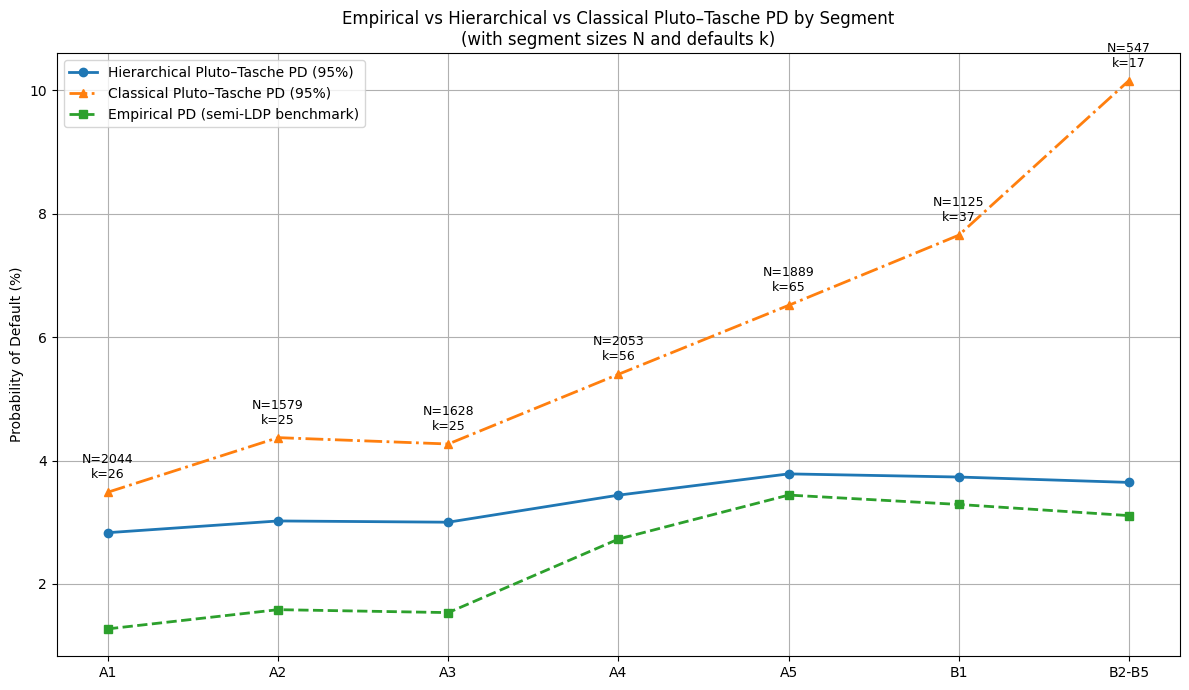

In [ ]:
# ------------------------------------------------------------
# Mean PD by segment for:
# - Hierarchical Pluto–Tasche
# - Classical Pluto–Tasche
# - Empirical semi-LDP benchmark
# ------------------------------------------------------------
plot_df_hier = (
    final_results
    .groupby("segment")
    .agg(PD_hier_mean=("PD_hierarchical_95", "mean"))
    .reset_index()
)

plot_df_classic = (
    final_results_classic
    .groupby("segment")
    .agg(PD_classic_mean=("PD_classic_95", "mean"))
    .reset_index()
)

plot_df_compare = (
    segmentation_df[["risk_segment", "n_observations", "n_defaults", "default_rate"]]
    .rename(columns={
        "risk_segment": "segment",
        "default_rate": "PD_semi"
    })
    .merge(plot_df_hier, on="segment", how="left")
    .merge(plot_df_classic, on="segment", how="left")
)

# Enforce correct segment order
segment_order = ["A1", "A2", "A3", "A4", "A5", "B1", "B2-B5"]
plot_df_compare["segment"] = pd.Categorical(
    plot_df_compare["segment"],
    categories=segment_order,
    ordered=True
)

plot_df_compare = plot_df_compare.sort_values("segment").reset_index(drop=True)

print(plot_df_compare)

segments_plot = plot_df_compare["segment"].astype(str).values
x = np.arange(len(segments_plot))

plt.figure(figsize=(12,7))

# Hierarchical PD
plt.plot(
    x,
    plot_df_compare["PD_hier_mean"] * 100,
    marker="o",
    linewidth=2,
    label="Hierarchical Pluto–Tasche PD (95%)"
)

# Classical PD
plt.plot(
    x,
    plot_df_compare["PD_classic_mean"] * 100,
    marker="^",
    linewidth=2,
    linestyle="-.",
    label="Classical Pluto–Tasche PD (95%)"
)

# Empirical benchmark
plt.plot(
    x,
    plot_df_compare["PD_semi"] * 100,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Empirical PD (semi-LDP benchmark)"
)

# N and k annotations
for i, row in plot_df_compare.iterrows():
    plt.annotate(
        f"N={int(row['n_observations'])}\nk={int(row['n_defaults'])}",
        (x[i], max(row["PD_hier_mean"], row["PD_classic_mean"], row["PD_semi"]) * 100),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

plt.xticks(x, segments_plot)
plt.ylabel("Probability of Default (%)")
plt.title("Empirical vs Hierarchical vs Classical Pluto–Tasche PD by Segment\n(with segment sizes N and defaults k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Le graphique met clairement en évidence les différences de comportement entre les **trois approches d’estimation de la PD par segment** : la **PD empirique** du semi-LDP, la **PD Pluto–Tasche hiérarchique** et la **PD Pluto–Tasche classique appliquée séparément à chaque segment**.

La première observation est que la **méthode de Pluto–Tasche classique appliquée segment par segment est systématiquement la plus prudente**. Pour l’ensemble des segments, la courbe orange se situe nettement au-dessus de la courbe empirique et également au-dessus de la courbe hiérarchique. Ce résultat est cohérent avec la logique même de la méthode : chaque segment est traité isolément, sans mutualisation d’information avec les autres segments. Dès lors, lorsque le nombre de défauts observés reste limité à l’intérieur d’un segment, le quantile prudent à 95 % conduit à une **surévaluation importante de la PD**, particulièrement marquée pour les segments les plus petits ou les moins bien renseignés.

Ce phénomène est particulièrement visible pour les segments les plus risqués et les moins fournis, notamment **B2-B5**, pour lequel la PD Pluto–Tasche classique dépasse **10 %**, contre environ **3,1 %** pour la PD empirique et **3,6 %** pour la version hiérarchique. Cela illustre bien le principal inconvénient de l’approche non hiérarchique : en l’absence de mécanisme de **shrinkage**, chaque segment supporte seul son incertitude statistique, ce qui peut conduire à des estimations très conservatrices, voire excessives.

À l’inverse, la **méthode hiérarchique** reste elle aussi **prudente**, puisque la courbe bleue est systématiquement au-dessus de la courbe empirique, mais elle est **beaucoup plus lisse et plus stable** que la méthode classique. Cela traduit précisément le rôle du modèle hiérarchique : il conserve une prudence réglementaire, tout en **mutualisant l’information entre segments** afin d’éviter les corrections trop extrêmes dues à la faiblesse des effectifs ou au faible nombre de défauts dans certains sous-portefeuilles.

Enfin, la courbe empirique conserve une structure économique cohérente, avec des PD plus faibles sur les segments **A1–A3** et plus élevées sur les segments **A4–B2-B5**. Les deux méthodes Pluto–Tasche respectent globalement cette hiérarchie, mais la version classique l’amplifie fortement, tandis que la version hiérarchique la conserve de manière plus modérée.

En résumé, ce graphique montre que :

* la **méthode Pluto–Tasche classique** est la **plus conservatrice**, mais aussi la plus sensible au manque d’information local ;
* la **méthode hiérarchique** constitue un **compromis plus équilibré**, en restant prudente tout en évitant des surestimations excessives ;
* la comparaison met ainsi en évidence l’intérêt pratique du **shrinkage hiérarchique** dans un cadre de **Low Default Portfolios segmentés**.



### 7.3 Relative-bias distributions


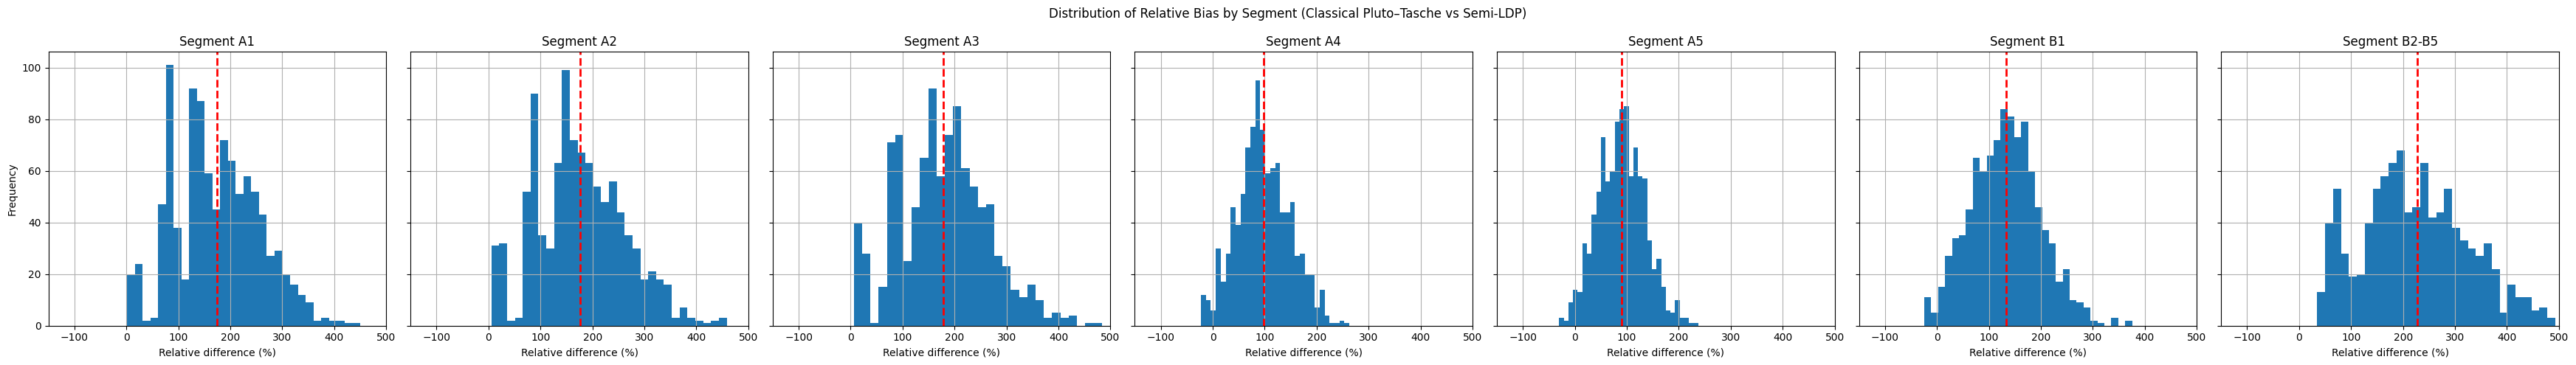

In [ ]:
# ------------------------------------------------------------
# Relative bias by segment
# Classical Pluto–Tasche vs Semi-LDP empirical PD
# ------------------------------------------------------------
lower_bound = -150
upper_bound = 500

segments_hist = segment_order

n_segments = len(segments_hist)
fig, axes = plt.subplots(1, n_segments, figsize=(5*n_segments, 5), sharey=True)

if n_segments == 1:
    axes = [axes]

for ax, seg in zip(axes, segments_hist):

    data = final_results_classic.loc[
        final_results_classic["segment"] == seg,
        "relative_difference_pct"
    ].dropna()

    zoomed_data = data[(data >= lower_bound) & (data <= upper_bound)]

    ax.hist(zoomed_data, bins=30)

    ax.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Segment {seg}")
    ax.set_xlabel("Relative difference (%)")
    ax.grid(True)
    ax.set_xlim(lower_bound, upper_bound)

axes[0].set_ylabel("Frequency")

plt.suptitle("Distribution of Relative Bias by Segment (Classical Pluto–Tasche vs Semi-LDP)")
plt.tight_layout()
plt.show()

### **Segment A1**

La distribution est **très largement positive** et centrée sur un niveau élevé. La méthode classique applique donc une **sur-prudence très marquée** sur **A1**.

### **Segment A2**

Même constat : la distribution est **nettement décalée vers la droite**, avec une moyenne encore plus élevée. La **PD Pluto–Tasche classique** est donc **très supérieure** à la PD empirique.

### **Segment A3**

La distribution reste **fortement positive** et assez étalée. La méthode classique conserve ici aussi un **biais prudentiel important**.

### **Segment A4**

La distribution est toujours **positive**, mais un peu moins extrême que sur **A1–A3**. La méthode reste **nettement prudente**, mais avec une correction relative plus modérée.

### **Segment A5**

La distribution est **plus resserrée** et centrée autour d’un niveau positif plus faible. La méthode classique reste **prudente**, mais l’écart relatif est moins extrême que sur les segments les plus sûrs.

### **Segment B1**

La distribution redevient **plus étalée** avec une moyenne positive marquée. La méthode classique produit donc encore une **surévaluation importante** de la PD sur **B1**.

### **Segment B2-B5**

La distribution est la **plus à droite** et l’une des plus dispersées. Cela montre que la méthode classique est **particulièrement conservatrice** sur ce segment, ce qui est cohérent avec sa **faible taille** et son **manque d’information locale**.




**On comprend ainsi que la méthode de Pluto–Tasche hiérarchique permet d’éviter une dérive excessive vers des estimations trop conservatrices.**

### 7.4 Absolute-bias distributions


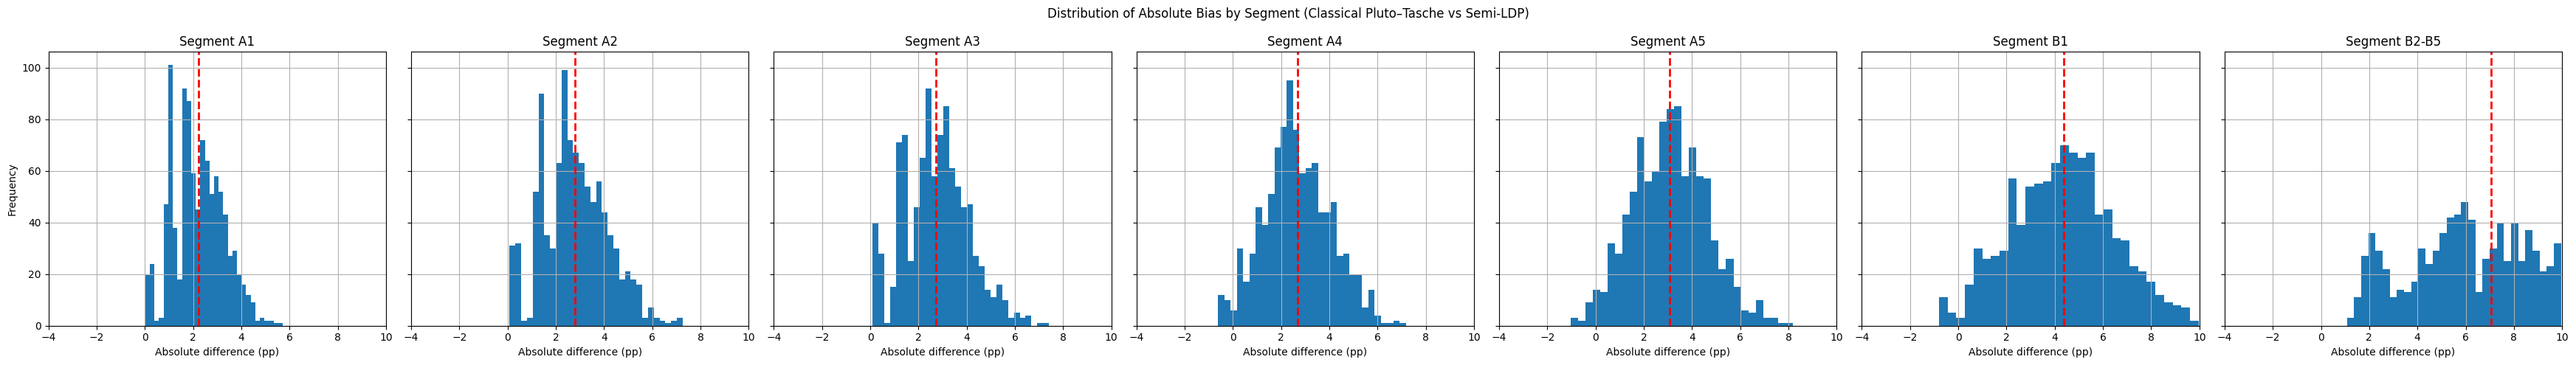

In [ ]:
# ------------------------------------------------------------
# Absolute bias by segment
# Classical Pluto–Tasche vs Semi-LDP empirical PD
# ------------------------------------------------------------
lower_bound = -4
upper_bound = 10

segments_hist = segment_order

n_segments = len(segments_hist)
fig, axes = plt.subplots(1, n_segments, figsize=(5*n_segments, 5), sharey=True)

if n_segments == 1:
    axes = [axes]

for ax, seg in zip(axes, segments_hist):

    data = final_results_classic.loc[
        final_results_classic["segment"] == seg,
        "diff_absolute_pp"
    ].dropna()

    zoomed_data = data[(data >= lower_bound) & (data <= upper_bound)]

    ax.hist(zoomed_data, bins=30)

    ax.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Segment {seg}")
    ax.set_xlabel("Absolute difference (pp)")
    ax.grid(True)
    ax.set_xlim(lower_bound, upper_bound)

axes[0].set_ylabel("Frequency")

plt.suptitle("Distribution of Absolute Bias by Segment (Classical Pluto–Tasche vs Semi-LDP)")
plt.tight_layout()
plt.show()

## 8. Wilson approach by segment


### 8.1 Segment-level Wilson estimator


In [ ]:
# ------------------------------------------------------------
# Wilson prudent PD = upper bound of Wilson interval
# ------------------------------------------------------------
def wilson_pd_upper(N: int, k: int, conf_level: float = 0.95) -> float:
    if N <= 0:
        return np.nan
    if (k < 0) or (k > N):
        return np.nan
    if (conf_level <= 0) or (conf_level >= 1):
        return np.nan

    alpha_sig = 1.0 - conf_level
    z = norm.ppf(1.0 - alpha_sig / 2.0)

    p_hat = k / N

    upper = (
        p_hat + (z**2) / (2 * N)
        + z * np.sqrt(p_hat * (1 - p_hat) / N + (z**2) / (4 * N**2))
    ) / (1 + (z**2) / N)

    return float(upper)

### 8.2 Wilson estimation across sampled portfolios


In [ ]:
# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
wilson_conf_level = 0.95
risk_segments = ["A1", "A2", "A3", "A4", "A5", "B1", "B2-B5"]

# ------------------------------------------------------------
# Apply Wilson segment by segment on each sampled LDP
# ------------------------------------------------------------
all_results_wilson = []

for idx, sample_df in enumerate(ldp_samples):

    summary = (
        sample_df
        .groupby("risk_segment")["default_flag"]
        .agg(N="count", k="sum")
        .reindex(risk_segments)
    )

    result_rows = []

    for seg in risk_segments:
        N_seg = summary.loc[seg, "N"]
        k_seg = summary.loc[seg, "k"]

        if pd.isna(N_seg) or pd.isna(k_seg):
            N_seg = 0
            k_seg = 0

        N_seg = int(N_seg)
        k_seg = int(k_seg)

        pd_wilson = wilson_pd_upper(
            N=N_seg,
            k=k_seg,
            conf_level=wilson_conf_level
        )

        result_rows.append({
            "ldp_id": idx,
            "segment": seg,
            "N_segment": N_seg,
            "k_segment": k_seg,
            "PD_wilson_95": pd_wilson
        })

    result_df = pd.DataFrame(result_rows)
    result_df["total_defaults_sample"] = int(sample_df["default_flag"].sum())

    all_results_wilson.append(result_df)

final_results_wilson = pd.concat(all_results_wilson, ignore_index=True)

print(final_results_wilson.head(12))
print("Number of rows in Wilson results:", len(final_results_wilson))

    ldp_id segment  N_segment  k_segment  PD_wilson_95  total_defaults_sample
0        0      A1        207          1      0.026852                     28
1        0      A2        136          3      0.062846                     28
2        0      A3        168          4      0.059612                     28
3        0      A4        205          5      0.055815                     28
4        0      A5        199          7      0.070816                     28
5        0      B1        112          5      0.100269                     28
6        0   B2-B5         59          3      0.139165                     28
7        1      A1        229          3      0.037802                     25
8        1      A2        160          4      0.062510                     25
9        1      A3        153          4      0.065287                     25
10       1      A4        220          5      0.052090                     25
11       1      A5        168          5      0.067770          

# **Merge avec la PD empirique benchmark + calcul des écarts**

In [ ]:
# ------------------------------------------------------------
# Merge benchmark empirical PD from semi-LDP
# ------------------------------------------------------------
semi_pd_dict = dict(zip(segmentation_df["risk_segment"], segmentation_df["default_rate"]))

final_results_wilson["PD_semi_ldp"] = final_results_wilson["segment"].map(semi_pd_dict)

# ------------------------------------------------------------
# Absolute difference (level)
# ------------------------------------------------------------
final_results_wilson["difference_vs_semi"] = (
    final_results_wilson["PD_wilson_95"]
    - final_results_wilson["PD_semi_ldp"]
)

# ------------------------------------------------------------
# Relative difference (%)
# ------------------------------------------------------------
final_results_wilson["relative_difference_pct"] = (
    final_results_wilson["difference_vs_semi"]
    / final_results_wilson["PD_semi_ldp"]
) * 100

# ------------------------------------------------------------
# Absolute difference in percentage points
# ------------------------------------------------------------
final_results_wilson["diff_absolute_pp"] = (
    final_results_wilson["PD_wilson_95"]
    - final_results_wilson["PD_semi_ldp"]
) * 100

print(final_results_wilson.head(12))

    ldp_id segment  N_segment  k_segment  PD_wilson_95  total_defaults_sample  \
0        0      A1        207          1      0.026852                     28   
1        0      A2        136          3      0.062846                     28   
2        0      A3        168          4      0.059612                     28   
3        0      A4        205          5      0.055815                     28   
4        0      A5        199          7      0.070816                     28   
5        0      B1        112          5      0.100269                     28   
6        0   B2-B5         59          3      0.139165                     28   
7        1      A1        229          3      0.037802                     25   
8        1      A2        160          4      0.062510                     25   
9        1      A3        153          4      0.065287                     25   
10       1      A4        220          5      0.052090                     25   
11       1      A5        16

### 8.3 Comparison of all PD estimators


  segment  n_observations  n_defaults   PD_semi  PD_hier_mean  \
0      A1            2044          26  0.012720      0.028313   
1      A2            1579          25  0.015833      0.030214   
2      A3            1628          25  0.015356      0.030011   
3      A4            2053          56  0.027277      0.034397   
4      A5            1889          65  0.034410      0.037844   
5      B1            1125          37  0.032889      0.037335   
6   B2-B5             547          17  0.031079      0.036462   

   PD_classic_mean  PD_wilson_mean  
0         0.034879        0.039547  
1         0.043721        0.049552  
2         0.042690        0.048364  
3         0.053990        0.059299  
4         0.065167        0.071090  
5         0.076540        0.084788  
6         0.101609        0.114729  


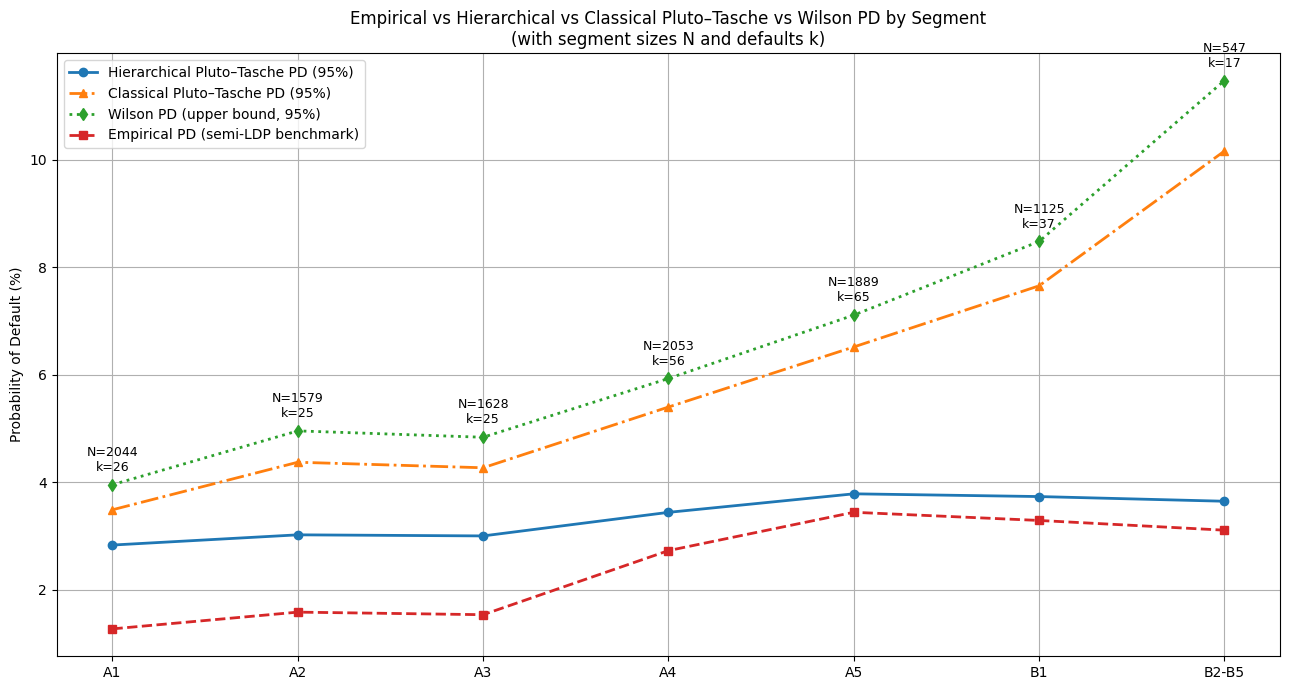

In [ ]:
# ------------------------------------------------------------
# Mean PD by segment for all methods
# ------------------------------------------------------------
plot_df_hier = (
    final_results
    .groupby("segment")
    .agg(PD_hier_mean=("PD_hierarchical_95", "mean"))
    .reset_index()
)

plot_df_classic = (
    final_results_classic
    .groupby("segment")
    .agg(PD_classic_mean=("PD_classic_95", "mean"))
    .reset_index()
)

plot_df_wilson = (
    final_results_wilson
    .groupby("segment")
    .agg(PD_wilson_mean=("PD_wilson_95", "mean"))
    .reset_index()
)

plot_df_compare_all = (
    segmentation_df[["risk_segment", "n_observations", "n_defaults", "default_rate"]]
    .rename(columns={
        "risk_segment": "segment",
        "default_rate": "PD_semi"
    })
    .merge(plot_df_hier, on="segment", how="left")
    .merge(plot_df_classic, on="segment", how="left")
    .merge(plot_df_wilson, on="segment", how="left")
)

segment_order = ["A1", "A2", "A3", "A4", "A5", "B1", "B2-B5"]
plot_df_compare_all["segment"] = pd.Categorical(
    plot_df_compare_all["segment"],
    categories=segment_order,
    ordered=True
)

plot_df_compare_all = plot_df_compare_all.sort_values("segment").reset_index(drop=True)

print(plot_df_compare_all)

segments_plot = plot_df_compare_all["segment"].astype(str).values
x = np.arange(len(segments_plot))

plt.figure(figsize=(13, 7))

# Hierarchical Pluto–Tasche
plt.plot(
    x,
    plot_df_compare_all["PD_hier_mean"] * 100,
    marker="o",
    linewidth=2,
    label="Hierarchical Pluto–Tasche PD (95%)"
)

# Classical Pluto–Tasche
plt.plot(
    x,
    plot_df_compare_all["PD_classic_mean"] * 100,
    marker="^",
    linewidth=2,
    linestyle="-.",
    label="Classical Pluto–Tasche PD (95%)"
)

# Wilson
plt.plot(
    x,
    plot_df_compare_all["PD_wilson_mean"] * 100,
    marker="d",
    linewidth=2,
    linestyle=":",
    label="Wilson PD (upper bound, 95%)"
)

# Empirical benchmark
plt.plot(
    x,
    plot_df_compare_all["PD_semi"] * 100,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Empirical PD (semi-LDP benchmark)"
)

# N and k annotations
for i, row in plot_df_compare_all.iterrows():
    plt.annotate(
        f"N={int(row['n_observations'])}\nk={int(row['n_defaults'])}",
        (x[i], max(
            row["PD_hier_mean"],
            row["PD_classic_mean"],
            row["PD_wilson_mean"],
            row["PD_semi"]
        ) * 100),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

plt.xticks(x, segments_plot)
plt.ylabel("Probability of Default (%)")
plt.title("Empirical vs Hierarchical vs Classical Pluto–Tasche vs Wilson PD by Segment\n(with segment sizes N and defaults k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Le graphique final met en évidence une hiérarchie claire entre les quatre approches d’estimation de la probabilité de défaut par segment : la **PD empirique** du semi-LDP, la **PD Pluto–Tasche hiérarchique**, la **PD Pluto–Tasche classique appliquée segment par segment** et la **borne supérieure de Wilson**.

La première observation est que, **dans notre cadre d’étude**, la **méthode de Wilson apparaît systématiquement comme la plus conservatrice**. Pour tous les segments, la courbe verte se situe au-dessus des trois autres, y compris au-dessus de la méthode de Pluto–Tasche classique. Cela signifie que la borne supérieure de Wilson fournit ici les estimations de PD les plus élevées. Ce résultat suggère que, dans des segments de taille limitée et avec peu de défauts observés, l’ajustement introduit par Wilson est particulièrement prudent.

La deuxième observation importante est que la **méthode de Pluto–Tasche classique** est elle aussi très conservatrice, mais reste globalement **en dessous de Wilson**. Elle amplifie fortement les PD segmentées, en particulier dans les segments les plus risqués ou les moins bien fournis, comme **B1** et surtout **B2-B5**. Cela confirme que l’absence de mutualisation entre segments conduit à des estimations très sensibles à l’information locale.

À l’inverse, la **méthode de Pluto–Tasche hiérarchique** apparaît comme la plus modérée des trois méthodes prudentes. Elle reste **systématiquement au-dessus de la PD empirique**, ce qui confirme son caractère conservateur, mais elle produit une courbe beaucoup plus **lisse**, **stable** et **contenue** que Wilson et Pluto–Tasche classique. C’est précisément l’effet attendu du **shrinkage hiérarchique** : conserver une prudence réglementaire tout en évitant les sur-ajustements extrêmes dans les segments les plus fragiles.

Le contraste est particulièrement marqué sur les segments les plus risqués, notamment **A5**, **B1** et **B2-B5**. Alors que la PD empirique reste autour de 3 à 3,5 %, la méthode hiérarchique se situe autour de 3,5 à 3,8 %, Pluto–Tasche classique monte entre environ 6,5 % et 10 %, et Wilson atteint même des niveaux supérieurs, dépassant **11 %** pour **B2-B5**. Cela montre que les méthodes non mutualisées, et en particulier Wilson ici, peuvent conduire à des estimations extrêmement prudentes lorsque l’information segmentée devient plus fragile.

Enfin, la **courbe empirique** conserve une **structure économique cohérente**, avec des **PD plus faibles** sur les segments **A1–A3** et **plus élevées** sur les segments **A4–B2-B5**. Les **trois méthodes prudentes** respectent globalement cette hiérarchie, mais avec des intensités différentes : la **méthode de Wilson** est celle qui **l’amplifie le plus fortement**, la **méthode de Pluto–Tasche classique** produit elle aussi une **amplification marquée**, tandis que la **version hiérarchique de Pluto–Tasche** préserve cette structure de manière **beaucoup plus modérée et plus lisse**.

L’enseignement principal de ce graphique est donc le suivant :

* **Wilson** est, dans cette application, la **méthode la plus conservatrice** ;
* **Pluto–Tasche classique** est également très prudent, mais légèrement moins extrême ;
* **Pluto–Tasche hiérarchique** constitue un **compromis plus équilibré**, en restant prudent tout en limitant les surestimations excessives ;
* la **PD empirique** demeure naturellement la référence la plus basse, puisqu’elle ne comporte aucun ajustement prudentiel.

Il faut toutefois formuler cette conclusion avec rigueur : ce résultat signifie que **Wilson est la plus conservatrice dans notre échantillon, avec notre segmentation et notre protocole de simulation**. Il ne faut pas l’interpréter comme une domination théorique universelle de Wilson sur toutes les autres méthodes. En revanche, **dans notre étude**, le constat empirique est sans ambiguïté.



### 8.4 Relative-bias distributions


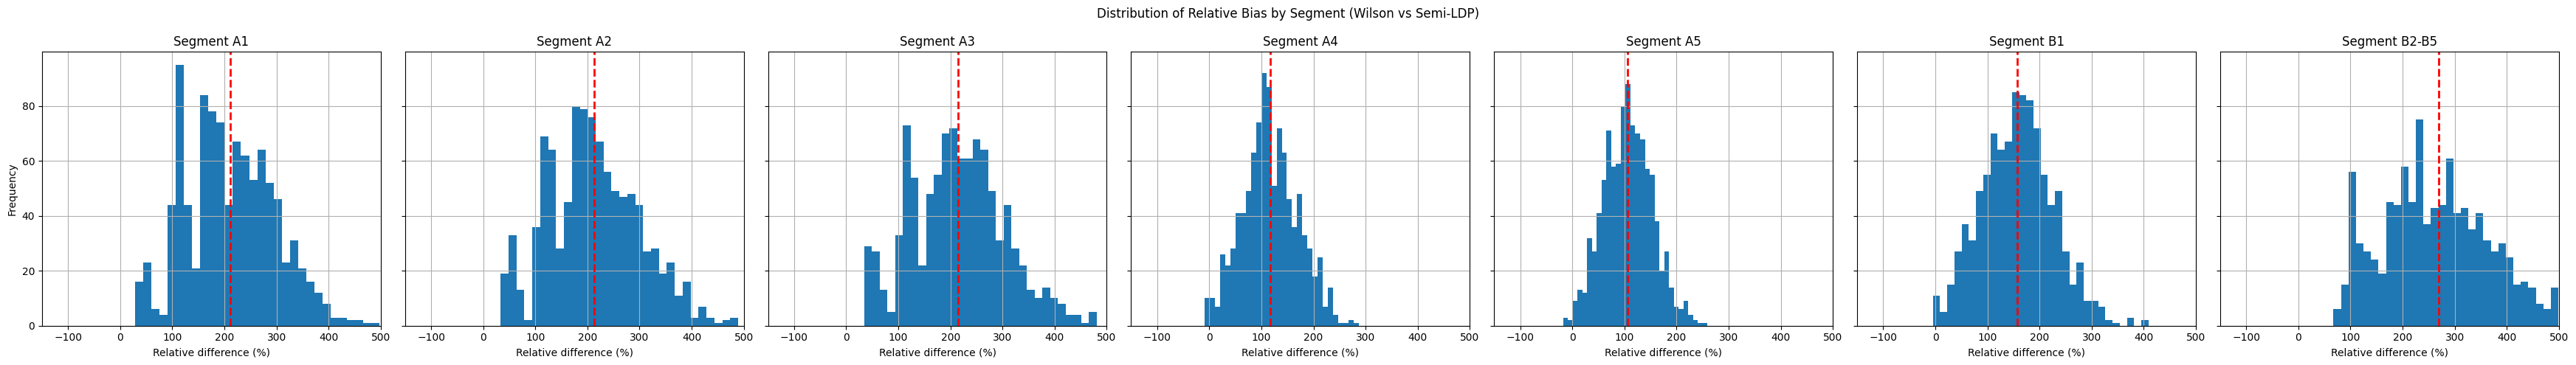

In [ ]:
# ------------------------------------------------------------
# Relative bias by segment
# Wilson vs Semi-LDP empirical PD
# ------------------------------------------------------------
lower_bound = -150
upper_bound = 500

segments_hist = segment_order
n_segments = len(segments_hist)

fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 5), sharey=True)

if n_segments == 1:
    axes = [axes]

for ax, seg in zip(axes, segments_hist):

    data = final_results_wilson.loc[
        final_results_wilson["segment"] == seg,
        "relative_difference_pct"
    ].dropna()

    zoomed_data = data[(data >= lower_bound) & (data <= upper_bound)]

    ax.hist(zoomed_data, bins=30)

    ax.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Segment {seg}")
    ax.set_xlabel("Relative difference (%)")
    ax.grid(True)
    ax.set_xlim(lower_bound, upper_bound)

axes[0].set_ylabel("Frequency")

plt.suptitle("Distribution of Relative Bias by Segment (Wilson vs Semi-LDP)")
plt.tight_layout()
plt.show()

### **Segment A1**

La distribution est **très nettement positive** et centrée à un niveau élevé. Wilson produit donc une **sur-prudence très marquée** sur **A1**.

### **Segment A2**

La distribution reste **fortement décalée vers la droite**, avec une moyenne encore plus élevée que sur A1. La **borne supérieure de Wilson** est donc **très largement au-dessus** de la PD empirique.

### **Segment A3**

Même logique : la distribution est **largement positive** et assez étalée. Wilson reste ici **très conservateur**, avec des écarts relatifs importants.

### **Segment A4**

La distribution est toujours **positive**, mais un peu moins extrême que sur **A1–A3**. Wilson demeure **nettement prudent**, tout en étant légèrement moins excessif sur ce segment intermédiaire.

### **Segment A5**

La distribution est **plus resserrée** et centrée autour d’un niveau positif plus modéré. Wilson reste **clairement conservateur**, mais l’écart relatif est moins fort que sur les segments les plus sûrs.

### **Segment B1**

La distribution se décale de nouveau vers des valeurs plus élevées, avec une moyenne positive marquée. Wilson applique donc encore une **surévaluation importante** de la PD sur **B1**.

### **Segment B2-B5**

C’est le segment le plus extrême : la distribution est **très à droite** et très dispersée. Wilson est ici **particulièrement conservateur**, ce qui est cohérent avec la **faible taille du segment** et l’**incertitude statistique élevée**.


Tous les segments présentent des **écarts relatifs positifs en moyenne**, ce qui confirme que **Wilson est systématiquement prudent** par rapport à la PD empirique. Et au vu du niveau des distributions, il apparaît ici **encore plus conservateur que Pluto–Tasche classique**, surtout sur les segments les plus petits ou les plus fragiles.


### 8.5 Absolute-bias distributions


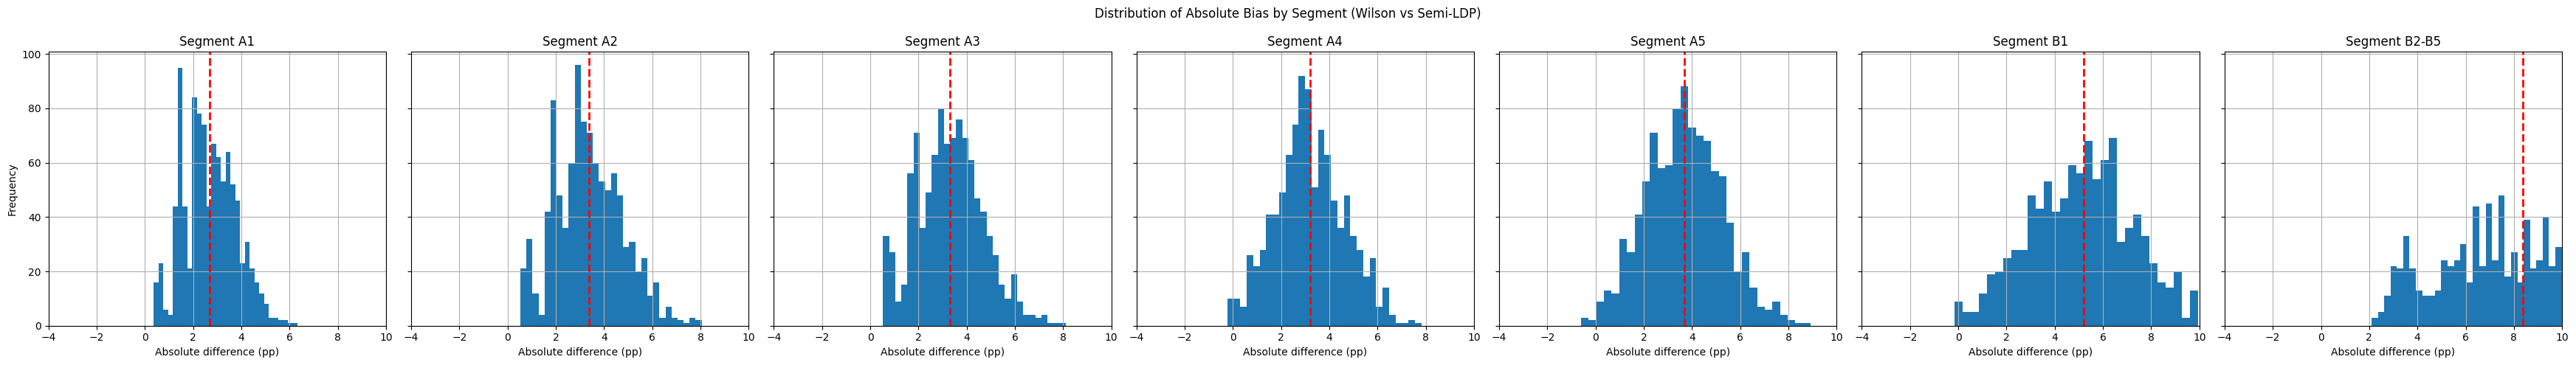

In [ ]:
# ------------------------------------------------------------
# Absolute bias by segment
# Wilson vs Semi-LDP empirical PD
# ------------------------------------------------------------
lower_bound = -4
upper_bound = 10

segments_hist = segment_order
n_segments = len(segments_hist)

fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 5), sharey=True)

if n_segments == 1:
    axes = [axes]

for ax, seg in zip(axes, segments_hist):

    data = final_results_wilson.loc[
        final_results_wilson["segment"] == seg,
        "diff_absolute_pp"
    ].dropna()

    zoomed_data = data[(data >= lower_bound) & (data <= upper_bound)]

    ax.hist(zoomed_data, bins=30)

    ax.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Segment {seg}")
    ax.set_xlabel("Absolute difference (pp)")
    ax.grid(True)
    ax.set_xlim(lower_bound, upper_bound)

axes[0].set_ylabel("Frequency")

plt.suptitle("Distribution of Absolute Bias by Segment (Wilson vs Semi-LDP)")
plt.tight_layout()
plt.show()

### 8.6 Segment-level summary


In [ ]:
# ------------------------------------------------------------
# Quick comparison table
# ------------------------------------------------------------
summary_compare_all = plot_df_compare_all.copy()

summary_compare_all["PD_semi_pct"] = summary_compare_all["PD_semi"] * 100
summary_compare_all["PD_hier_mean_pct"] = summary_compare_all["PD_hier_mean"] * 100
summary_compare_all["PD_classic_mean_pct"] = summary_compare_all["PD_classic_mean"] * 100
summary_compare_all["PD_wilson_mean_pct"] = summary_compare_all["PD_wilson_mean"] * 100

summary_compare_all["Hier_minus_Semi_pp"] = (
    summary_compare_all["PD_hier_mean_pct"] - summary_compare_all["PD_semi_pct"]
)

summary_compare_all["Classic_minus_Semi_pp"] = (
    summary_compare_all["PD_classic_mean_pct"] - summary_compare_all["PD_semi_pct"]
)

summary_compare_all["Wilson_minus_Semi_pp"] = (
    summary_compare_all["PD_wilson_mean_pct"] - summary_compare_all["PD_semi_pct"]
)

print(summary_compare_all[[
    "segment",
    "PD_semi_pct",
    "PD_hier_mean_pct",
    "PD_classic_mean_pct",
    "PD_wilson_mean_pct",
    "Hier_minus_Semi_pp",
    "Classic_minus_Semi_pp",
    "Wilson_minus_Semi_pp"
]])

  segment  PD_semi_pct  PD_hier_mean_pct  PD_classic_mean_pct  \
0      A1     1.272016          2.831349             3.487894   
1      A2     1.583281          3.021371             4.372115   
2      A3     1.535627          3.001133             4.268987   
3      A4     2.727716          3.439722             5.398988   
4      A5     3.440974          3.784380             6.516651   
5      B1     3.288889          3.733538             7.654040   
6   B2-B5     3.107861          3.646214            10.160887   

   PD_wilson_mean_pct  Hier_minus_Semi_pp  Classic_minus_Semi_pp  \
0            3.954660            1.559334               2.215879   
1            4.955216            1.438091               2.788835   
2            4.836447            1.465507               2.733361   
3            5.929868            0.712006               2.671273   
4            7.108977            0.343406               3.075677   
5            8.478791            0.444649               4.365151   
6  

## 9. Full Wilson intervals and final comparison


### 9.1 Full Wilson interval


In [ ]:
# ------------------------------------------------------------
# Wilson interval: lower, upper, midpoint
# ------------------------------------------------------------
def wilson_interval(N: int, k: int, conf_level: float = 0.95):
    if N <= 0:
        return np.nan, np.nan, np.nan
    if (k < 0) or (k > N):
        return np.nan, np.nan, np.nan
    if (conf_level <= 0) or (conf_level >= 1):
        return np.nan, np.nan, np.nan

    alpha_sig = 1.0 - conf_level
    z = norm.ppf(1.0 - alpha_sig / 2.0)

    p_hat = k / N

    lower = (
        p_hat + (z**2) / (2 * N)
        - z * np.sqrt(p_hat * (1 - p_hat) / N + (z**2) / (4 * N**2))
    ) / (1 + (z**2) / N)

    upper = (
        p_hat + (z**2) / (2 * N)
        + z * np.sqrt(p_hat * (1 - p_hat) / N + (z**2) / (4 * N**2))
    ) / (1 + (z**2) / N)

    mean_interval = (lower + upper) / 2.0

    return float(lower), float(upper), float(mean_interval)

### 9.2 Segment-level interval estimation


In [ ]:
# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
wilson_conf_level = 0.95
risk_segments = ["A1", "A2", "A3", "A4", "A5", "B1", "B2-B5"]

# ------------------------------------------------------------
# Apply Wilson interval segment by segment on each sampled LDP
# ------------------------------------------------------------
all_results_wilson = []

for idx, sample_df in enumerate(ldp_samples):

    summary = (
        sample_df
        .groupby("risk_segment")["default_flag"]
        .agg(N="count", k="sum")
        .reindex(risk_segments)
    )

    result_rows = []

    for seg in risk_segments:
        N_seg = summary.loc[seg, "N"]
        k_seg = summary.loc[seg, "k"]

        if pd.isna(N_seg) or pd.isna(k_seg):
            N_seg = 0
            k_seg = 0

        N_seg = int(N_seg)
        k_seg = int(k_seg)

        wilson_lower, wilson_upper, wilson_mean = wilson_interval(
            N=N_seg,
            k=k_seg,
            conf_level=wilson_conf_level
        )

        result_rows.append({
            "ldp_id": idx,
            "segment": seg,
            "N_segment": N_seg,
            "k_segment": k_seg,
            "PD_wilson_lower_95": wilson_lower,
            "PD_wilson_upper_95": wilson_upper,
            "PD_wilson_mean_95": wilson_mean
        })

    result_df = pd.DataFrame(result_rows)
    result_df["total_defaults_sample"] = int(sample_df["default_flag"].sum())

    all_results_wilson.append(result_df)

final_results_wilson = pd.concat(all_results_wilson, ignore_index=True)

print(final_results_wilson.head(12))
print("Number of rows in Wilson results:", len(final_results_wilson))

    ldp_id segment  N_segment  k_segment  PD_wilson_lower_95  \
0        0      A1        207          1            0.000853   
1        0      A2        136          3            0.007530   
2        0      A3        168          4            0.009297   
3        0      A4        205          5            0.010462   
4        0      A5        199          7            0.017142   
5        0      B1        112          5            0.019217   
6        0   B2-B5         59          3            0.017443   
7        1      A1        229          3            0.004465   
8        1      A2        160          4            0.009764   
9        1      A3        153          4            0.010213   
10       1      A4        220          5            0.009746   
11       1      A5        168          5            0.012778   

    PD_wilson_upper_95  PD_wilson_mean_95  total_defaults_sample  
0             0.026852           0.013853                     28  
1             0.062846           

### 9.3 Average estimates by segment


In [ ]:
# ------------------------------------------------------------
# Mean PD by segment for all methods
# ------------------------------------------------------------
plot_df_hier = (
    final_results
    .groupby("segment")
    .agg(PD_hier_mean=("PD_hierarchical_95", "mean"))
    .reset_index()
)

plot_df_classic = (
    final_results_classic
    .groupby("segment")
    .agg(PD_classic_mean=("PD_classic_95", "mean"))
    .reset_index()
)

plot_df_wilson = (
    final_results_wilson
    .groupby("segment")
    .agg(
        PD_wilson_lower_mean=("PD_wilson_lower_95", "mean"),
        PD_wilson_upper_mean=("PD_wilson_upper_95", "mean"),
        PD_wilson_mid_mean=("PD_wilson_mean_95", "mean")
    )
    .reset_index()
)

plot_df_compare_all = (
    segmentation_df[["risk_segment", "n_observations", "n_defaults", "default_rate"]]
    .rename(columns={
        "risk_segment": "segment",
        "default_rate": "PD_semi"
    })
    .merge(plot_df_hier, on="segment", how="left")
    .merge(plot_df_classic, on="segment", how="left")
    .merge(plot_df_wilson, on="segment", how="left")
)

segment_order = ["A1", "A2", "A3", "A4", "A5", "B1", "B2-B5"]
plot_df_compare_all["segment"] = pd.Categorical(
    plot_df_compare_all["segment"],
    categories=segment_order,
    ordered=True
)

plot_df_compare_all = plot_df_compare_all.sort_values("segment").reset_index(drop=True)

print(plot_df_compare_all)

  segment  n_observations  n_defaults   PD_semi  PD_hier_mean  \
0      A1            2044          26  0.012720      0.028313   
1      A2            1579          25  0.015833      0.030214   
2      A3            1628          25  0.015356      0.030011   
3      A4            2053          56  0.027277      0.034397   
4      A5            1889          65  0.034410      0.037844   
5      B1            1125          37  0.032889      0.037335   
6   B2-B5             547          17  0.031079      0.036462   

   PD_classic_mean  PD_wilson_lower_mean  PD_wilson_upper_mean  \
0         0.034879              0.004577              0.039547   
1         0.043721              0.005553              0.049552   
2         0.042690              0.005523              0.048364   
3         0.053990              0.012562              0.059299   
4         0.065167              0.016770              0.071090   
5         0.076540              0.013619              0.084788   
6         0.10160

### 9.4 Final comparison with Wilson intervals


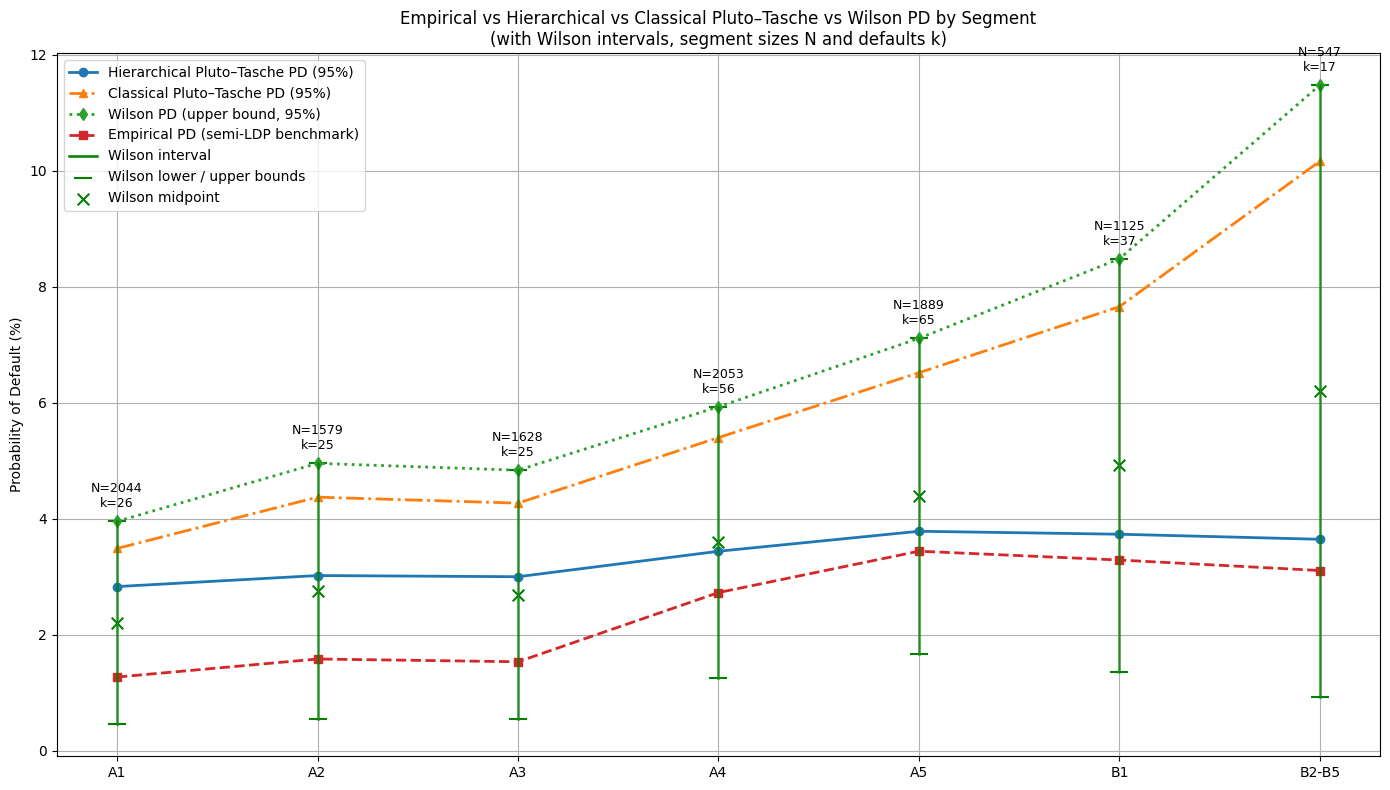

In [ ]:
segments_plot = plot_df_compare_all["segment"].astype(str).values
x = np.arange(len(segments_plot))

plt.figure(figsize=(14, 8))

# ------------------------------------------------------------
# Hierarchical Pluto–Tasche
# ------------------------------------------------------------
plt.plot(
    x,
    plot_df_compare_all["PD_hier_mean"] * 100,
    marker="o",
    linewidth=2,
    label="Hierarchical Pluto–Tasche PD (95%)"
)

# ------------------------------------------------------------
# Classical Pluto–Tasche
# ------------------------------------------------------------
plt.plot(
    x,
    plot_df_compare_all["PD_classic_mean"] * 100,
    marker="^",
    linewidth=2,
    linestyle="-.",
    label="Classical Pluto–Tasche PD (95%)"
)

# ------------------------------------------------------------
# Wilson upper bound curve
# ------------------------------------------------------------
plt.plot(
    x,
    plot_df_compare_all["PD_wilson_upper_mean"] * 100,
    marker="d",
    linewidth=2,
    linestyle=":",
    label="Wilson PD (upper bound, 95%)"
)

# ------------------------------------------------------------
# Empirical benchmark
# ------------------------------------------------------------
plt.plot(
    x,
    plot_df_compare_all["PD_semi"] * 100,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Empirical PD (semi-LDP benchmark)"
)

# ------------------------------------------------------------
# Wilson interval per segment:
# lower / midpoint / upper connected vertically
# ------------------------------------------------------------
for i, row in plot_df_compare_all.iterrows():
    wilson_lower = row["PD_wilson_lower_mean"] * 100
    wilson_mid   = row["PD_wilson_mid_mean"] * 100
    wilson_upper = row["PD_wilson_upper_mean"] * 100

    # Vertical line connecting lower -> mid -> upper
    plt.plot(
        [x[i], x[i], x[i]],
        [wilson_lower, wilson_mid, wilson_upper],
        color="green",
        alpha=0.8,
        linewidth=1.8
    )

    # Mark the three Wilson points
    plt.scatter(x[i], wilson_lower, color="green", marker="_", s=180)
    plt.scatter(x[i], wilson_mid,   color="green", marker="x", s=70)
    plt.scatter(x[i], wilson_upper, color="green", marker="_", s=180)

# ------------------------------------------------------------
# Add legend entries for Wilson interval components
# ------------------------------------------------------------
plt.plot([], [], color="green", linewidth=1.8, label="Wilson interval")
plt.scatter([], [], color="green", marker="_", s=180, label="Wilson lower / upper bounds")
plt.scatter([], [], color="green", marker="x", s=70, label="Wilson midpoint")

# ------------------------------------------------------------
# N and k annotations
# ------------------------------------------------------------
for i, row in plot_df_compare_all.iterrows():
    plt.annotate(
        f"N={int(row['n_observations'])}\nk={int(row['n_defaults'])}",
        (
            x[i],
            max(
                row["PD_hier_mean"],
                row["PD_classic_mean"],
                row["PD_wilson_upper_mean"],
                row["PD_semi"]
            ) * 100
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

plt.xticks(x, segments_plot)
plt.ylabel("Probability of Default (%)")
plt.title("Empirical vs Hierarchical vs Classical Pluto–Tasche vs Wilson PD by Segment\n(with Wilson intervals, segment sizes N and defaults k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Le graphique final permet de synthétiser de manière très claire les relations entre les **quatre approches d’estimation** considérées : la **PD empirique** du semi-LDP, la **PD Pluto–Tasche hiérarchique**, la **PD Pluto–Tasche classique**, ainsi que la **méthode de Wilson** à travers sa **borne supérieure**, sa **borne inférieure** et le **centre de l’intervalle**.

Un premier résultat important est que, **conformément à la théorie**, la **PD empirique**, que l’on prend ici comme notre meilleure approximation de la “vraie" PD segmentée, est **toujours supérieure à la borne inférieure de Wilson**. Cela est rassurant, car cela signifie que l’intervalle de Wilson n’est pas construit de manière aberrante : la borne basse reste bien en dessous du niveau de risque effectivement observé dans le semi-LDP.

Deuxième point essentiel : les **intervalles de Wilson contiennent systématiquement toutes les estimations de PD obtenues pour chaque segment**. Autrement dit, pour chacun des segments, la **PD empirique**, la **PD Pluto–Tasche hiérarchique** et la **PD Pluto–Tasche classique** se situent toutes à l’intérieur de l’intervalle de confiance de Wilson. Ce résultat est particulièrement intéressant, car il montre qu’au-delà de fournir une simple borne prudente, la méthode de Wilson offre aussi un **cadre naturel pour quantifier la variabilité plausible des estimations de PD**. En ce sens, elle ne sert pas seulement à produire une estimation conservatrice ; elle fournit également une **mesure explicite de l’incertitude** autour de la PD de chaque segment.

Un troisième enseignement du graphique est que **l’approche Pluto–Tasche hiérarchique est systématiquement celle qui se situe le plus près du centre des intervalles de Wilson**. Cela confirme une fois de plus le rôle de cette méthode comme **compromis équilibré** entre prudence et stabilité. Elle reste au-dessus de la PD empirique, donc conserve un caractère conservateur, mais elle évite les niveaux beaucoup plus élevés atteints par Pluto–Tasche classique et par la borne supérieure de Wilson. Le fait qu’elle soit proche du centre de l’intervalle de Wilson suggère qu’elle capte une forme de **niveau central prudent**, sans tomber dans l’excès de conservatisme.

Enfin, on observe un point assez frappant : la **borne supérieure de Wilson** semble se comporter comme un **décalage global vers le haut** par rapport aux autres estimations prudentes, en particulier par rapport à **Pluto–Tasche classique**. Sur les segments **A1 à A5**, l’écart entre Wilson upper et Pluto–Tasche classique est de l’ordre de **0,4 à 0,6 point de pourcentage**, ce qui donne effectivement l’impression d’un **shift vertical relativement stable**. Cet effet devient ensuite plus marqué sur les segments les plus fragiles, notamment **B1** et surtout **B2-B5**, où l’écart dépasse plutôt **0,8 à 1,3 point de pourcentage**. On peut donc dire qu’il existe bien un **décalage vers le haut d’ordre de grandeur voisin d’un demi-point à un point de PD**, avec une amplification sur les segments les moins bien renseignés.

Au total, ce graphique conduit à une lecture assez nette :

* **Wilson** fournit la structure d’intervalle la plus complète et la plus prudente ;
* **Pluto–Tasche classique** reste très conservatrice, mais moins que Wilson ;
* **Pluto–Tasche hiérarchique** apparaît comme la méthode la plus équilibrée, car elle reste prudente tout en se situant proche du centre des intervalles de Wilson ;
* la **PD empirique**, enfin, reste naturellement le point de référence le plus bas, puisqu’elle ne comporte aucun ajustement prudentiel.

En pratique, cela renforce l’idée que **Wilson est un excellent outil pour encadrer l’incertitude**, tandis que **Pluto–Tasche hiérarchique semble fournir la meilleure estimation prudentielle centrale** dans notre cadre segmenté.
